In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.utils import resample
from scipy.stats import norm
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

A:OLS for the Runge function
-

Write your own code (using for example the pseudoinverse function pinv from numpy, or
the SVD directly) and perform a standard ordinary least squares regression analysis using
polynomials in x up to order 15 or higher.

In [22]:
def runge(x):
    return (1.0/(1.0+25*x**2))

def design_matrix(x, degree):
    X = np.vander(np.asarray(x).ravel(), degree +1 , increasing=True)
    return X


rng = np.random.default_rng(2026)
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)


def exercisedata(x, y, d):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)
    scaler = StandardScaler()
    Xtr = design_matrix(x_train, d)
    
    Xtr_sc = np.copy(Xtr)
    Xtr_sc[:,1:] = scaler.fit_transform(Xtr[:,1:]) 
    

    Xte = design_matrix(x_test, d)
    Xte_sc = np.copy(Xte)
    Xte_sc[:,1:] = scaler.transform(Xte[:,1:]) 
    theta = np.linalg.lstsq(Xtr_sc, y_train, rcond=None)[0]

    return theta, Xtr_sc, Xte_sc, y_train, y_test


degrees = np.arange(1,16)

mse_train, mse_test = [], []
R2_train, R2_test = [], []
theta_values = []

for d in degrees:
    theta, Xtr_sc, Xte_sc, y_train, y_test = exercisedata(x, y, d)
    theta_values.append(theta)
    y_train_pred = Xtr_sc @ theta
    y_test_pred = Xte_sc @ theta
    mse_train.append(mean_squared_error(y_train, y_train_pred))
    mse_test.append(mean_squared_error(y_test, y_test_pred))
    R2_train.append(r2_score(y_train, y_train_pred))
    R2_test.append(r2_score(y_test, y_test_pred))

Lowest Test MSE: 0.018711534420669352 Measured at degree: 8


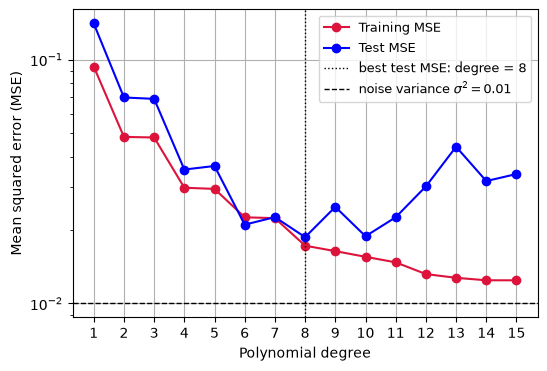

In [23]:
#best_degree = degrees[int(np.argmin(mse_test))]
#print("Lowest Test MSE:", mse_test[best_degree], "Meassured at degree:", best_degree)
best_idx = int(np.argmin(mse_test))
best_degree = degrees[best_idx]

print("Lowest Test MSE:", mse_test[best_idx],"Measured at degree:", best_degree)
plt.figure(figsize=(6,4))
plt.plot(degrees, mse_train, "o-", color = "crimson", label = "Training MSE")
plt.plot(degrees, mse_test, "o-", color = "blue", label = "Test MSE")
plt.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree = {best_degree}")
plt.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise variance $\sigma ^2 = 0.01$")
plt.xlabel("Polynomial degree"); plt.ylabel("Mean squared error (MSE)"); plt.xticks(degrees); plt.legend(fontsize=9), plt.grid(True)
plt.yscale("log"); plt.savefig("ols_mse.png", dpi=300, bbox_inches="tight");plt.show()

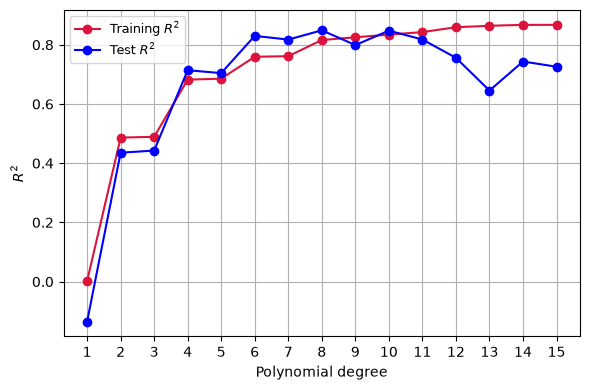

In [24]:
plt.figure(figsize=(6,4)); plt.plot(degrees, R2_train, "o-", color = "crimson", label = "Training $R^2$")
plt.plot(degrees, R2_test, "o-", color = "blue", label = "Test $R^2$")
plt.xlabel("Polynomial degree"); plt.ylabel("$R^2$"); plt.xticks(degrees); plt.legend(fontsize=9),
plt.grid(True); plt.tight_layout();plt.savefig("ols_R2.png", dpi=300, bbox_inches="tight");plt.show()

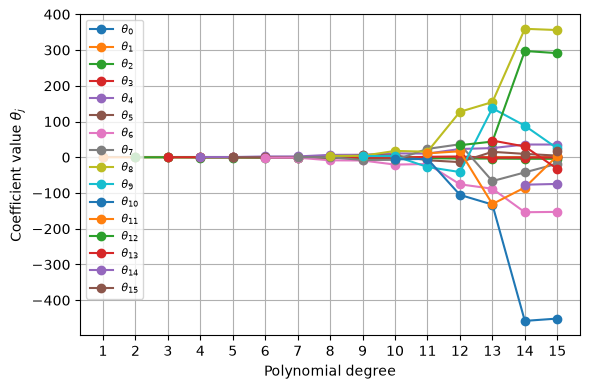

In [25]:
max_degree = max(degrees)

plt.figure(figsize=(6, 4))

for j in range(max_degree + 1):
    theta_j = [
        theta[j] if j < len(theta) else np.nan
        for theta in theta_values
    ]
    plt.plot(degrees, theta_j, "o-", label=rf"$\theta_{{{j}}}$")

plt.xlabel("Polynomial degree")
plt.ylabel(r"Coefficient value $\theta_j$")
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig("ols_Coeff.png", dpi=300, bbox_inches="tight")
plt.show()

B: Adding Ridge regression for the Runge function
-

In [26]:
best_results = []
lambdas = np.logspace(-6,0,100)
degree = np.arange(1,16)
for d in degree:

    theta, Xtr_sc, Xte_sc, yr_train, yr_test = exercisedata(x, y, d)
    I = np.eye(Xtr_sc.shape[1])
    I[0,0] = 0
    mse_r_train, mse_r_test = [], []
    R2_r_train, R2_r_test = [], []
    theta_r_values = []
    for l in lambdas:

        theta_r = np.linalg.solve(Xtr_sc.T @ Xtr_sc + len(yr_train)*l*I, Xtr_sc.T@yr_train)
        theta_r_values.append(theta_r)

        yr_train_pred = Xtr_sc@ theta_r
        yr_test_pred = Xte_sc @ theta_r

        mse_r_train.append(mean_squared_error(yr_train, yr_train_pred))
        mse_r_test.append(mean_squared_error(yr_test, yr_test_pred))

        R2_r_train.append(r2_score(yr_train, yr_train_pred))
        R2_r_test.append(r2_score(yr_test, yr_test_pred))
    best_idx = int(np.argmin(mse_r_test))
    best_results.append((d, lambdas[best_idx], mse_r_test[best_idx]))

    theta_r_values = np.array(theta_r_values)

best_degree, best_lambda, best_mse = min(best_results, key=lambda result: result[2])

print("Beste grad:", best_degree)
print("Beste lambda:", best_lambda)
print("Laveste test-MSE:", best_mse)

Beste grad: 8
Beste lambda: 1.873817422860383e-05
Laveste test-MSE: 0.01765544134057781


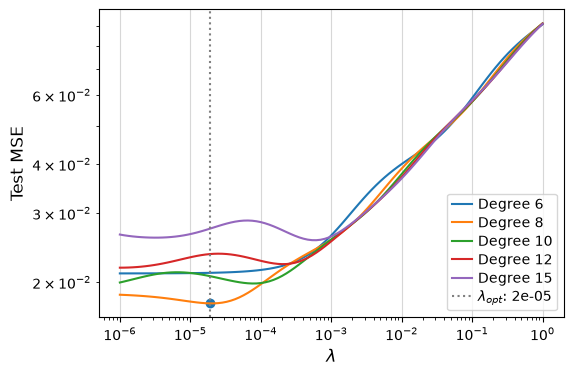

Lowest test MSE: 0.01766
Degree: 8
Lambda: 1.87e-05


In [30]:
plt.figure(figsize=(6,4))

best = (np.inf, None, None)  # (test-MSE, grad, lambda)
degrees = [6, 8, 10, 12, 15]
for d in degrees:
    _, Xtr_sc, Xte_sc, yr_train, yr_test = exercisedata(x, y, d)

    I = np.eye(Xtr_sc.shape[1])
    I[0, 0] = 0  # Ikke straff konstantleddet
    mse_test = []

    for lam in lambdas:
        theta = np.linalg.solve(Xtr_sc.T @ Xtr_sc + len(yr_train) * lam * I,Xtr_sc.T @ yr_train)
        mse = mean_squared_error(yr_test, Xte_sc @ theta)
        mse_test.append(mse)

        if mse < best[0]:
            best = (mse, d, lam)

    plt.loglog(lambdas, mse_test, label=f"Degree {d}")

plt.axvline(best[2], color="gray", ls=":", label=r"$\lambda_{opt}$:" rf" {best[2]:.1g}")
#plt.axhline(best[0], color="gray", ls=":", label=rf"")
plt.scatter(best[2], best[0]);plt.xlabel(r"$\lambda$", fontsize=12);plt.ylabel("Test MSE", fontsize=12)
#;plt.legend(fontsize=9)
plt.legend(loc="lower right",fontsize=10,borderpad=0.3,labelspacing=0.3,handlelength=1.5,handletextpad=0.4)
plt.grid(True, which="major", alpha=0.5);plt.tight_layout
plt.show()
print(f"Lowest test MSE: {best[0]:.5f}")
print(f"Degree: {best[1]}")
print(f"Lambda: {best[2]:.3g}")

In [35]:
theta, Xtr_sc, Xte_sc, yr_train, yr_test = exercisedata(x, y, d=8)
I = np.eye(Xtr_sc.shape[1])
I[0,0] = 0
mse_r_train, mse_r_test = [], []
R2_r_train, R2_r_test = [], []
theta_r_values = []
lambdas = np.logspace(-6,0,100)
degree = np.arange(1,16)
for l in lambdas:

    theta_r = np.linalg.solve(Xtr_sc.T @ Xtr_sc + len(y_train)*l*I, Xtr_sc.T@yr_train)
    theta_r_values.append(theta_r)

    yr_train_pred = Xtr_sc@ theta_r
    yr_test_pred = Xte_sc @ theta_r

    mse_r_train.append(mean_squared_error(yr_train, yr_train_pred))
    mse_r_test.append(mean_squared_error(yr_test, yr_test_pred))

    R2_r_train.append(r2_score(yr_train, yr_train_pred))
    R2_r_test.append(r2_score(yr_test, yr_test_pred))

theta_r_values = np.array(theta_r_values)

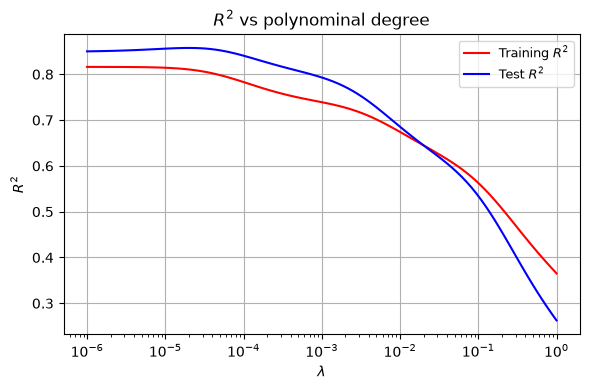

In [36]:
plt.figure(figsize=(6,4))
plt.semilogx(lambdas, R2_r_train, color = "r", label = "Training $R^2$")
plt.semilogx(lambdas, R2_r_test, color = "blue", label = "Test $R^2$")
plt.xlabel(fr"$\lambda$"); plt.ylabel("$R^2$"); plt.legend(fontsize=9),
plt.grid(True); plt.title("$R^2$ vs polynominal degree"); plt.tight_layout();plt.show()

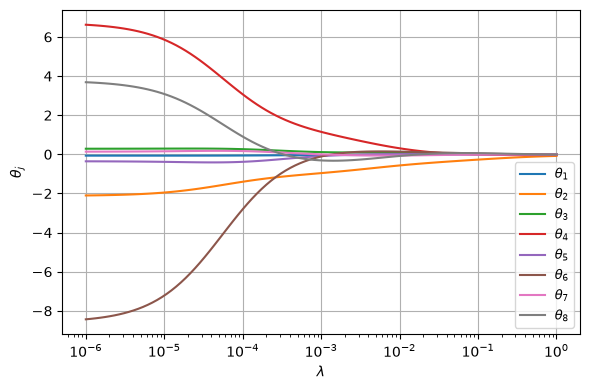

In [37]:
plt.figure(figsize=(6,4))
for j in range(1, theta_r_values.shape[1]):
    plt.semilogx(lambdas, theta_r_values[:, j], label = rf"$\theta_{j}$")

plt.xlabel(r"$\lambda$"); plt.ylabel(r"$\theta_j$");
plt.legend(fontsize=9); plt.tight_layout();plt.grid(True);plt.savefig("Ridge_coeff_lam.png", dpi=300, bbox_inches="tight"); plt.show()

C: The bias-variance tradeoff and the bootstrap method
-

In [13]:
import pandas as pd
import numpy as np

summary_rows = []

def add_result(model, sigma, resampling, degree, mse, lam=np.nan):
    new_row = {"Model": model,"Sigma": sigma,"Resampling": resampling,"Degree": int(degree),"Lambda": lam,"MSE": float(mse)}

    for i, row in enumerate(summary_rows):
        if ( row["Model"] == model and row["Sigma"] == sigma and row["Resampling"] == resampling):summary_rows[i] = new_row
        return

    summary_rows.append(new_row)

In [44]:
def runge_data(degree, n=100, sigma = 0.1, seed = 2026):
    rng = np.random.default_rng(seed)
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    
    mse_tr_c, mse_te_c, theta_values = [], [], []

    for d in degree:
        theta, Xtr_sc, Xte_sc, y_train, y_test =  exercisedata(x, y, d)
    
        theta_values.append(theta)
        y_train_pred = Xtr_sc @ theta
        y_test_pred = Xte_sc @ theta

        mse_tr_c.append(mean_squared_error(y_train, y_train_pred))
        mse_te_c.append(mean_squared_error(y_test, y_test_pred))

    return np.array(mse_tr_c), np.array(mse_te_c), theta_values

n = 40: Laveste test-MSE = 0.018712, optimal grad = 8
n = 100: Laveste test-MSE = 0.021463, optimal grad = 6
n = 400: Laveste test-MSE = 0.018712, optimal grad = 8


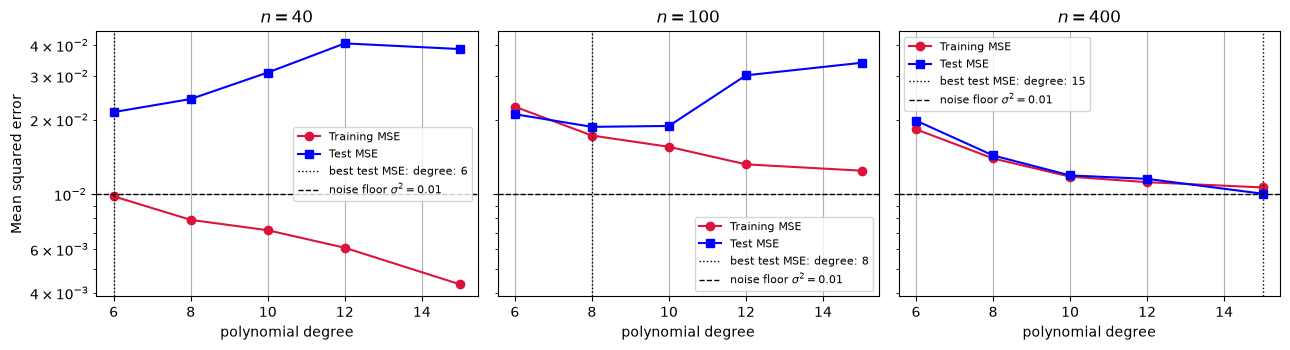

In [45]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, n_ in zip(axes, (40, 100, 400)):
    best_idx = int(np.argmin(mse_te))
    best_degree = degrees[best_idx]
    best_mse = mse_te[best_idx]

    print(f"n = {n_}: Laveste test-MSE = {best_mse:.6f}, "f"optimal grad = {best_degree}")
    results.append({
    "Antall datapunkter": n_,
    "Optimal grad": best_degree,
    "Laveste test-MSE": best_mse})

    mse_tr, mse_te, _ = runge_data(degree=degrees, n=n_, sigma = 0.1, seed = 2026)
    best_degree = degrees[int(np.argmin(mse_te))]
    ax.plot(degrees, mse_tr,"o-", color = "crimson", label = "Training MSE")
    ax.plot(degrees, mse_te,"s-", color = "b", label = f"Test MSE")
    ax.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
    ax.axhline(0.1**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = 0.01$")
    ax.set_yscale("log")
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("polynomial degree")
    ax.grid(True)
    ax.legend(fontsize= 8)

axes[0].set_ylabel("Mean squared error")

plt.tight_layout()
plt.show()

In [ ]:
table = pd.DataFrame(results)
display(table.style.format({"Laveste test-MSE": "{:.6f}"}))

n = 400: Laveste test-MSE = 1.251303, optimal grad = 2
n = 400: Laveste test-MSE = 0.001343, optimal grad = 15
n = 400: Laveste test-MSE = 0.018712, optimal grad = 8


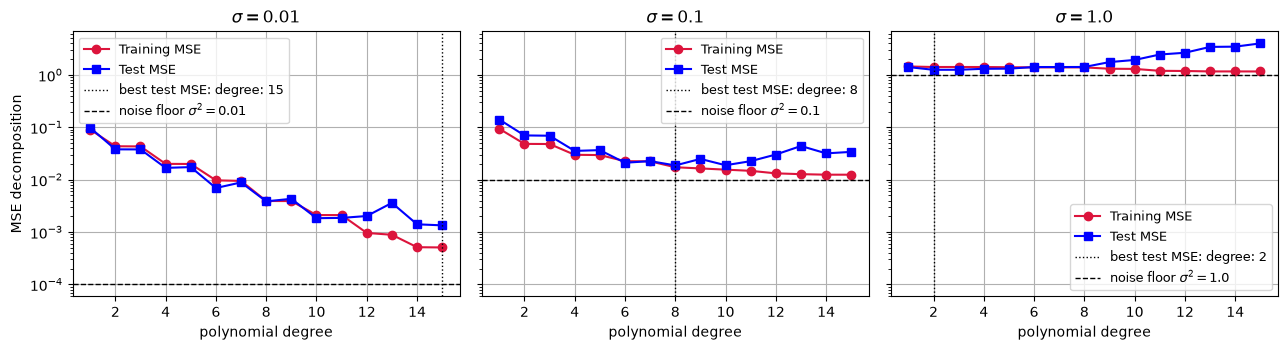

In [ ]:
results = []
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, s_ in zip(axes, (0.01, 0.1, 1.0)):
    best_idx = int(np.argmin(mse_te))
    best_degree = degrees[best_idx]
    best_mse = mse_te[best_idx]
    
    print(f"s = {s_}: Laveste test-MSE = {best_mse:.6f}, "f"optimal grad = {best_degree}")
    print(f"s = {s_}: Laveste test-MSE = {best_mse:.6f}, "f"optimal grad = {best_degree}")
    results.append({"noise": s_,
        "Optimal grad": best_degree,
        "Laveste test-MSE": best_mse})
    mse_tr, mse_te, _ = runge_data(degree=degrees, n=100, sigma = s_, seed = 2026)
    best_degree = degrees[int(np.argmin(mse_te))]
    ax.plot(degrees, mse_tr,"o-", color = "crimson", label = "Training MSE")
    ax.plot(degrees, mse_te,"s-", color = "b", label = f"Test MSE")
    ax.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"best test MSE: degree: {best_degree}")
    ax.axhline(s_**2, color = "k", ls = "--", lw=1, label=f"noise floor $\sigma ^2 = {s_}$")
    ax.set_yscale("log")
    ax.set_title(f"$\sigma = {s_}$")
    ax.set_xlabel("polynomial degree")
    ax.legend(fontsize= 9)
    ax.grid(True)

axes[0].set_ylabel("MSE decomposition")
plt.legend(fontsize= 9); plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
table = pd.DataFrame(results)
display(table.style.format({"Laveste test-MSE": "{:.6f}"}))

Bias-variance analasys of the runge function using the boot-starp method
-

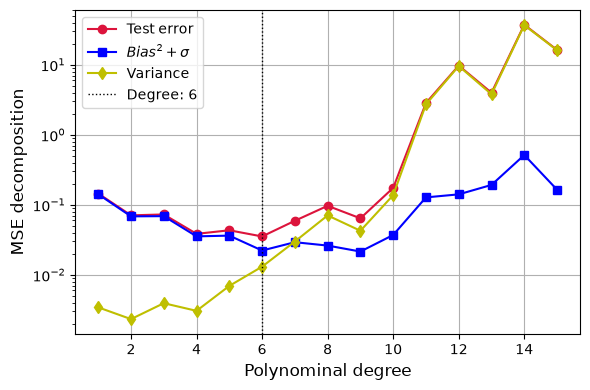

In [46]:
np.random.seed(2026)

n, n_bootstrap, maxdegree = 100, 100, 15
degrees = np.arange(1, maxdegree +1)
rng = np.random.default_rng(2026)
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
x = np.asarray(x).reshape(-1, 1)
y = runge(x) + rng.normal(0, sigma, size = (n, 1))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2026)


error = np.zeros(maxdegree)
bias = np.zeros(maxdegree)
variance = np.zeros(maxdegree)
for j, degree in enumerate(degrees):
    
    model = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression(fit_intercept=False))
    y_pred = np.empty((y_test.shape[0], n_bootstrap))
    for i in range(n_bootstrap):
        x_, y_ = resample(x_train, y_train)
        y_pred[:,i] = model.fit(x_, y_).predict(x_test).ravel()

    error[j] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
    bias[j] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
    variance[j] = np.mean(np.var(y_pred, axis=1, keepdims=True))

idx = int(np.argmin(error))
best_degree = degrees[idx]

plt.subplots(figsize=(6,4))
plt.plot(degrees, error, "o-", color = "crimson", label = "Test error")
plt.plot(degrees, bias, "s-", color = "b", label = r"$Bias^2 + \sigma$")
plt.plot(degrees, variance, "d-", color = "y", label = "Variance")
plt.axvline(best_degree, color = "k", ls = ":", lw=1, label=f"Degree: {best_degree}")
#plt.axhline(error[idx], color = "k", ls = ":", lw=1, label=f" MSE:{error[idx]:.3f}")
plt.xlabel("Polynominal degree", fontsize=12); plt.ylabel("MSE decomposition", fontsize=12)
plt.yscale("log"); plt.legend(fontsize=10); plt.grid(True); plt.tight_layout()
plt.show()

In [48]:
add_result("OLS", 0.1, "Bootstrap",degrees[idx], error[idx])
print("OLS", 0.1, "Bootstrap",degrees[idx], error[idx])

OLS 0.1 Bootstrap 6 0.035344523036631235


In [49]:
deg = np.arange(1, 16)
table = pd.DataFrame({"Degree": deg, "Error": error ,"Bias": bias, "variance": variance , "sum":sum})
display(table.style.format(precision=4).hide(axis="index"))

Degree,Error,Bias,variance,sum
1,0.1450,0.1415,0.0034,
2,0.0707,0.0684,0.0023,
3,0.0728,0.0689,0.0039,
4,0.0385,0.0354,0.0031,
5,0.0433,0.0363,0.0070,
6,0.0353,0.0223,0.0131,
7,0.0592,0.0292,0.0299,
8,0.0967,0.0262,0.0706,
9,0.0641,0.0215,0.0426,
10,0.1745,0.0371,0.1374,


In [50]:
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14,n_bootstraps=100, make_model=None, seed=2026):
    if make_model is None:
        make_model = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),LinearRegression(fit_intercept=False))

    np.random.seed(seed)
    rng = np.random.default_rng(seed)

    x = np.sort(rng.uniform(-1, 1, n)).reshape(-1, 1)
    y = runge(x) + rng.normal(0, noise, size=(n, 1))

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=seed)

    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))

    for j, degree in enumerate(range(1, maxdegree + 1)):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))

        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

        error[j] = np.mean((y_test - y_pred)**2)
        bias[j] = np.mean(
            (y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[j] = np.mean(np.var(y_pred, axis=1))

    return error, bias, variance

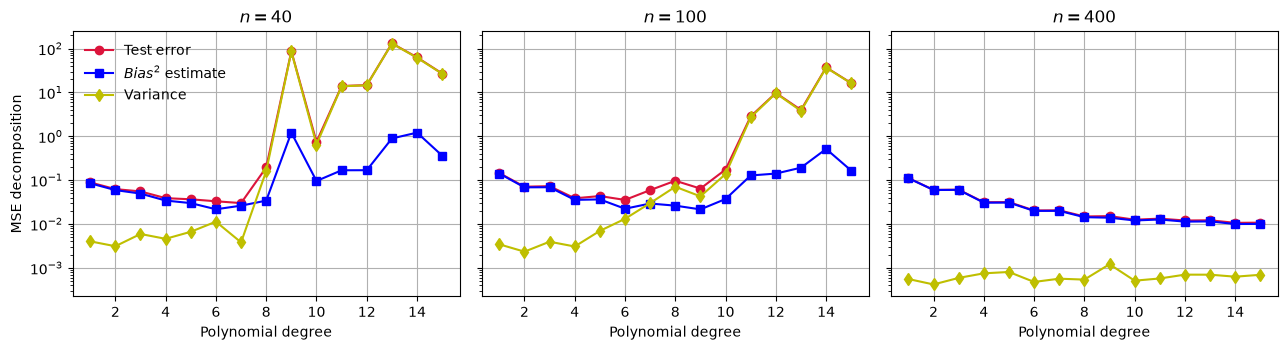

In [211]:
maxdegree = 15
degrees = np.arange(1, maxdegree + 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)

for ax, n_ in zip(axes, (40, 100, 400)):
    err, b2, var = bias_variance_sweep(n=n_, maxdegree=maxdegree)

    ax.plot(degrees, err, "o-", color="crimson", label="Test error")
    ax.plot(degrees, b2, "s-", color="b", label=r"$Bias^2$ estimate")
    ax.plot(degrees, var, "d-", color="y", label="Variance")

    ax.set_yscale("log")
    
    ax.grid(True)
    ax.set_title(f"$n = {n_}$")
    ax.set_xlabel("Polynomial degree")

axes[0].set_ylabel("MSE decomposition")
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

In [51]:
maxdegree = 15
degrees = np.arange(1, maxdegree + 1)

err2, b2, var2 = bias_variance_sweep(n=100, noise=0.05, maxdegree=maxdegree)

idx2 = int(np.argmin(err2))
best_degree2 = degrees[idx2]

print(f"sigma=0.05: MSE={err2[idx2]:.4f}, degree={best_degree2}")


sigma=0.05: MSE=0.0191, degree=6


In [52]:
idx2 = int(np.argmin(err2))
add_result("OLS", 0.05, "Bootstrap",degrees[idx2], err2[idx2])

Bootstrap med Ridge

In [54]:
lambdas = np.logspace(-6, 0, 100)
rows = []
for lam in lambdas:
    def make_model(deg, lam=lam):
        return make_pipeline(PolynomialFeatures(degree=deg, include_bias=False), StandardScaler(),Ridge(alpha=lam))
    err, b2, var = bias_variance_sweep(n=100,maxdegree=15,make_model=make_model)
    for j, d in enumerate(range(1, maxdegree + 1)): 
        rows.append({"Degree": d,"Lambda": lam,"Error": err[j],"Bias": b2[j],"Variance": var[j] })

In [55]:
table_lambda = pd.DataFrame(rows)

best_bootstrap = table_lambda.loc[table_lambda["Error"].idxmin()]
print(f"Beste grad: {int(best_bootstrap['Degree'])}")
print(f"Beste lambda: {best_bootstrap['Lambda']:.3e}")
print(f"Bootstrap-MSE: {best_bootstrap['Error']:.5f}")

Beste grad: 6
Beste lambda: 4.037e-02
Bootstrap-MSE: 0.02987


In [56]:
best_lambda = best_bootstrap["Lambda"]
table_ridge = (table_lambda.loc[table_lambda["Lambda"] == best_lambda,["Degree", "Error", "Bias", "Variance"]].sort_values("Degree").copy())
table_ridge["Sum"] = table_ridge["Bias"] + table_ridge["Variance"]
print(f"Lambda brukt i tabellen: {best_lambda:.3e}")
print(table_ridge.to_latex(index=False, float_format="%.4f"))

Lambda brukt i tabellen: 4.037e-02
\begin{tabular}{rrrrr}
\toprule
Degree & Error & Bias & Variance & Sum \\
\midrule
1 & 0.1450 & 0.1415 & 0.0034 & 0.1450 \\
2 & 0.0708 & 0.0684 & 0.0023 & 0.0708 \\
3 & 0.0728 & 0.0689 & 0.0039 & 0.0728 \\
4 & 0.0385 & 0.0355 & 0.0030 & 0.0385 \\
5 & 0.0424 & 0.0363 & 0.0061 & 0.0424 \\
6 & 0.0299 & 0.0233 & 0.0066 & 0.0299 \\
7 & 0.0310 & 0.0232 & 0.0079 & 0.0310 \\
8 & 0.0365 & 0.0243 & 0.0122 & 0.0365 \\
9 & 0.0441 & 0.0273 & 0.0168 & 0.0441 \\
10 & 0.0429 & 0.0275 & 0.0154 & 0.0429 \\
11 & 0.0533 & 0.0305 & 0.0229 & 0.0533 \\
12 & 0.0830 & 0.0265 & 0.0565 & 0.0830 \\
13 & 0.0437 & 0.0285 & 0.0152 & 0.0437 \\
14 & 0.0521 & 0.0318 & 0.0202 & 0.0521 \\
15 & 0.0458 & 0.0309 & 0.0149 & 0.0458 \\
\bottomrule
\end{tabular}



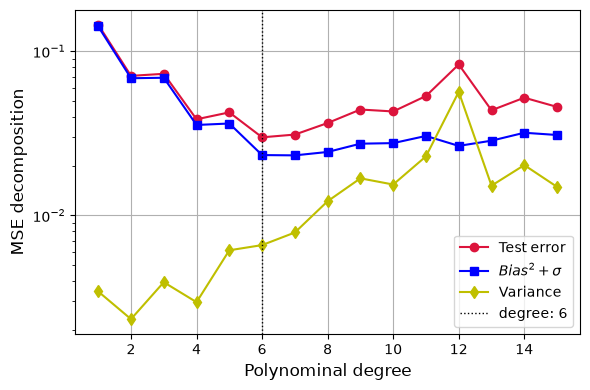

In [57]:
plt.subplots(figsize=(6,4))
plt.plot(table_ridge["Degree"], table_ridge["Error"], "o-", color = "crimson", label = "Test error")
plt.plot(table_ridge["Degree"], table_ridge["Bias"], "s-", color = "b", label = r"$Bias^2 + \sigma$")
plt.plot(table_ridge["Degree"], table_ridge["Variance"], "d-", color = "y", label = "Variance")
plt.axvline(int(best_bootstrap['Degree']), color = "k", ls = ":", lw=1, label=f"degree: {int(best_bootstrap['Degree'])}")
#plt.axhline(best_bootstrap['Error'], color = "k", ls = ":", lw=1, label=f" MSE:{best_bootstrap['Error']:.3f}")
plt.xlabel("Polynominal degree", fontsize=12); plt.ylabel("MSE decomposition", fontsize=12)
plt.yscale("log"); plt.legend(fontsize=10); plt.grid(True); plt.tight_layout()
plt.show()

In [ ]:
lambdas = np.logspace(-6, 0, 100)
rows2 = []
for lam in lambdas:
    def make_model(deg, lam=lam):
        return make_pipeline(PolynomialFeatures(degree=deg, include_bias=False), StandardScaler(),Ridge(alpha=lam))

    err, b2, var = bias_variance_sweep(n=100,noise=0.05, maxdegree=15,make_model=make_model)

    for j, d in enumerate(range(1, maxdegree + 1)): 
        rows2.append({"Degree": d,"Lambda": lam,"Error": err[j],"Bias": b2[j],"Variance": var[j] })

In [437]:
table_lambda2 = pd.DataFrame(rows2)

best_bootstrap2 = table_lambda2.loc[table_lambda2["Error"].idxmin()]

print(f"Beste grad: {int(best_bootstrap2['Degree'])}")
print(f"Beste lambda: {best_bootstrap2['Lambda']:.3e}")
print(f"Bootstrap-MSE: {best_bootstrap2['Error']:.5f}")

Beste grad: 7
Beste lambda: 4.642e-02
Bootstrap-MSE: 0.01363


In [438]:
for sigma, table in [(0.1, table_lambda), (0.05, table_lambda2)]:
    best = table.loc[table["Error"].idxmin()]

    add_result("Ridge", sigma, "Bootstrap",best["Degree"], best["Error"], best["Lambda"])

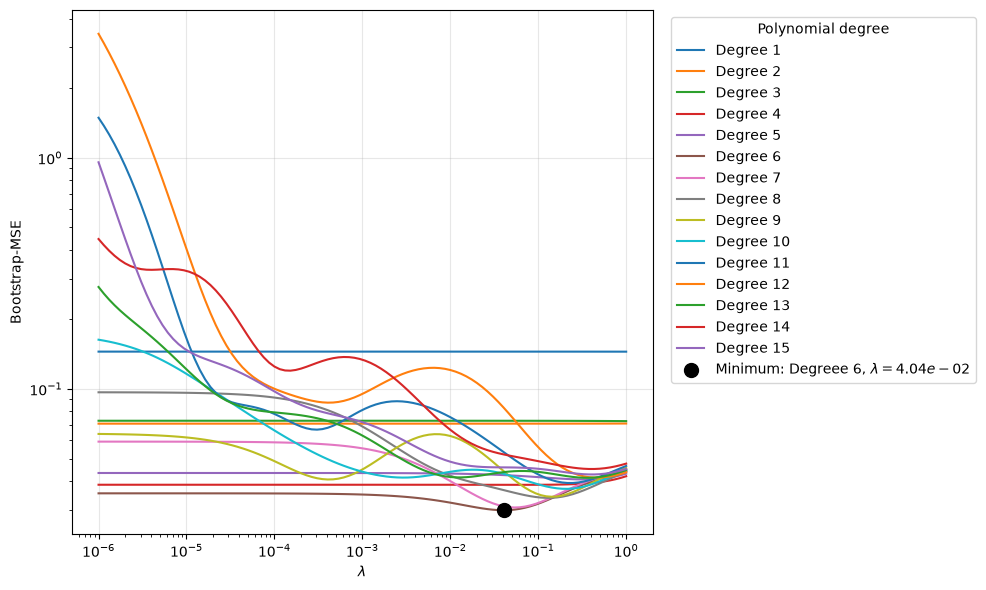

In [19]:
table_lambda = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 6))

for d in range(1, 16):
    data = table_lambda[table_lambda["Degree"] == d].sort_values("Lambda")
    ax.loglog((data["Lambda"]), data["Error"], label=f"Degree {d}")
ax.scatter(
best_bootstrap["Lambda"],
best_bootstrap["Error"],
color="black", s=100, zorder=10,
label=f"Minimum: Degreee {int(best_bootstrap['Degree'])}, "
  rf"$\lambda={best_bootstrap['Lambda']:.2e}$"
)
    
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("Bootstrap-MSE")
ax.grid(True, alpha=0.3)
ax.legend(title="Polynomial degree", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

D: Cross-validation as a resampling technique
-

In [440]:
mx_degree = 15
degrees = np.arange(1, mx_degree +1)
rng = np.random.default_rng(2026)
n = 100
sigma = 0.1
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)

def ols_k_fold(x,y, mx_degree, n_splits=5):
    
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).ravel()
    kf = KFold(n_splits, shuffle = True, random_state=2026)
    cv_mse = np.zeros(mx_degree)
    for i, deg in enumerate(range(1, mx_degree + 1)):
        pipe = make_pipeline(PolynomialFeatures(degree = deg), LinearRegression(fit_intercept=False))
        scores = -cross_val_score(pipe, x, y.ravel(), cv = kf, scoring="neg_mean_squared_error")
        cv_mse[i] = scores.mean() 

    return cv_mse

CV selects degree 11 (CV-MSE 0.0211129064)
CV selects degree 11 (CV-MSE 0.0202372654)


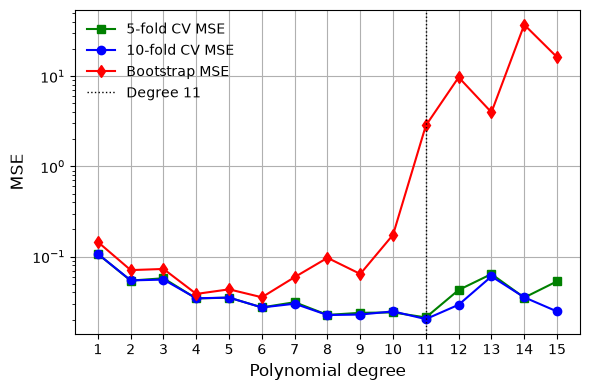

In [441]:
cv_mse5 = ols_k_fold(x,y, mx_degree, n_splits=5)
cv_mse10 = ols_k_fold(x,y, mx_degree, n_splits=10)

best_deg5 = np.argmin(cv_mse5) + 1
best_deg10 = np.argmin(cv_mse10) + 1

print(f"CV selects degree {best_deg5} (CV-MSE {cv_mse5[best_deg5-1]:.10f})")
print(f"CV selects degree {best_deg10} (CV-MSE {cv_mse10[best_deg10-1]:.10f})")

fig, ax = plt.subplots(figsize=(6.0, 4.0))
ax.plot(degrees, cv_mse5, "s-", color='g', label="5-fold CV MSE")
ax.plot(degrees, cv_mse10, "o-", color='b', label="10-fold CV MSE")
ax.plot(degrees, error, "d-", color = "r", label = "Bootstrap MSE ")

idx = int(np.argmin(cv_mse5))
best_degree = degrees[idx]
best_mse = cv_mse5[idx]

ax.axvline(best_degree, color = "k", ls=":", lw=1,label=f"Degree {best_degree}")
#ax.axhline( best_mse, ls="--", color = "k",lw=1,label=f"MSE {best_mse:.4f}")

ax.set_xticks(np.arange(1, 16))
#ax.plot(best_deg5, cv_mse5[best_deg5], "o", color='b', ms=10, label="CV minimum")
#ax.plot(best_deg10, cv_mse10[best_deg10], "o", color='b', ms=10, label="CV minimum")
ax.set_yscale("log")
ax.grid()
ax.set_xlabel("Polynomial degree", fontsize = 12)
ax.set_ylabel(" MSE ", fontsize = 12)
ax.legend(frameon=False, fontsize = 10);plt.tight_layout()
plt.show()

In [442]:
sigma = 0.1  
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, 100))
y = runge(x) + rng.normal(0, sigma, size=x.shape)

cv_mse5 = ols_k_fold(x, y, mx_degree, n_splits=5)
cv_mse10 = ols_k_fold(x, y, mx_degree, n_splits=10)

for name, mse_values in [
    ("5-fold CV", cv_mse5),("10-fold CV", cv_mse10)]:
    idx = int(np.argmin(mse_values))
    best_degree = idx + 1  # Hvis funksjonen tester grad 1 til mx_degree
    best_mse = mse_values[idx]

    add_result("OLS", sigma, name, best_degree, best_mse)
    print(f"{name}, sigma={sigma}: "f"degree={best_degree}, MSE={best_mse:.10f}")

5-fold CV, sigma=0.1: degree=11, MSE=0.0211129064
10-fold CV, sigma=0.1: degree=11, MSE=0.0202372654


In [443]:
n = 100
sigma = 0.05
rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma,n)

err, b2, var = bias_variance_sweep(n=100, noise=0.05, maxdegree=maxdegree)
idx = int(np.argmin(err))
best_degree = degrees[idx]

print(f"sigma:0.05: {err[idx]:.4f}, degree:{best_degree}")


cv_mse5s = ols_k_fold(x,y, mx_degree, n_splits=5)
cv_mse10s = ols_k_fold(x,y, mx_degree, n_splits=10)

best_deg5 = np.argmin(cv_mse5s) + 1
best_deg10 = np.argmin(cv_mse10s) + 1

print(f"CV selects degree {best_deg5} (CV-MSE {cv_mse5s[best_deg5-1]:.10f})")
print(f"CV selects degree {best_deg10} (CV-MSE {cv_mse10s[best_deg10-1]:.10f})")



sigma:0.05: 0.0191, degree:6
CV selects degree 14 (CV-MSE 0.0068692314)
CV selects degree 14 (CV-MSE 0.0074566905)


In [444]:
sigma = 0.05  # Bytt til 0.05 for det andre forsøket

rng = np.random.default_rng(2026)
x = np.sort(rng.uniform(-1, 1, 100))
y = runge(x) + rng.normal(0, sigma, size=x.shape)

cv_mse5 = ols_k_fold(x, y, mx_degree, n_splits=5)
cv_mse10 = ols_k_fold(x, y, mx_degree, n_splits=10)

for name, mse_values in [("5-fold CV", cv_mse5),("10-fold CV", cv_mse10)]:
    idx = int(np.argmin(mse_values))
    best_degree = idx + 1  # Hvis funksjonen tester grad 1 til mx_degree
    best_mse = mse_values[idx]

    add_result("OLS", sigma, name, best_degree, best_mse)

    print(f"{name}, sigma={sigma}: "f"degree={best_degree}, MSE={best_mse:.10f}")

5-fold CV, sigma=0.05: degree=14, MSE=0.0068692314
10-fold CV, sigma=0.05: degree=14, MSE=0.0074566905


From the figure one observes that the cv selects degree 11 as the optimal degree for both k_fold equal to 5 and 10. This is quite different from the OLS that gave 5 and the bootstrap suggested degree 6. 

In [425]:
#degrees_ols = np.arange(mx_degree)  # Funksjonen din bruker range(mx_degree)
degrees_ols = np.arange(1, mx_degree + 1)
ols_table = pd.DataFrame({"Degree": degrees_ols,"5-fold CV-MSE": cv_mse5s,"10-fold CV-MSE": cv_mse10s})
display(ols_table.style.format({"5-fold CV-MSE": "{:.6f}","10-fold CV-MSE": "{:.6f}"}).hide(axis="index"))

Degree,5-fold CV-MSE,10-fold CV-MSE
1,0.097679,0.097697
2,0.045795,0.045667
3,0.047324,0.046195
4,0.023451,0.023517
5,0.024738,0.024261
6,0.014891,0.014872
7,0.017071,0.016391
8,0.009317,0.009006
9,0.009989,0.010330
10,0.008711,0.008740


In [445]:
# Bytt mse_ols5 og mse_ols10 med dine variabelnavn.
sigma = 0.05

for name, mse_values in [("5-fold CV", cv_mse5s),("10-fold CV", cv_mse10s)]:
    idx = int(np.argmin(mse_values))
    add_result("OLS", sigma, name,degrees[idx], mse_values[idx])

In [446]:
def RIDGE_k_fold(x, y, nlambdas, lambdas, k=5, degree=12):
    x = np.asarray(x).reshape(-1, 1)
    y = np.asarray(y).ravel()
    
    mse_kr = np.zeros(nlambdas)
    std_kr = np.zeros(nlambdas)

    kfold = KFold(n_splits=k, shuffle=True, random_state=2026)
    
    for i, lmb in enumerate(lambdas):
        pipe = make_pipeline(PolynomialFeatures(degree=degree), StandardScaler(), Ridge(alpha=lmb))
        scores = cross_val_score(pipe,x, y, cv = kfold, scoring="neg_mean_squared_error")
        mse_kr[i] = np.mean(-scores)
        std_kr[i] = scores.std()
    return mse_kr, std_kr

In [447]:
rng = np.random.default_rng(2026)
sigma = 0.1
n = 100
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma, size = n)   

lambdas = np.logspace(-6, 0, n)
degrees = np.arange(1, 16)
nlam = len(lambdas)

#kf_data = np.zeros(len(degrees), len(lambdas))
kf_mse = np.zeros((len(degrees), nlam))
kf_std = np.zeros((len(degrees), nlam))

for i, deg in enumerate(degrees):
    #for j, l in enumerate(lambdas):
    kf_mse5, kf_std5 = RIDGE_k_fold(x, y, nlam, lambdas=lambdas, k=5, degree=deg)
    kf_mse[i, :] = kf_mse5
    kf_std[i, :] = kf_std5

best_i, best_j = np.unravel_index(np.argmin(kf_mse), kf_mse.shape)

best_d = degrees[best_i]
best_l = lambdas[best_j]
best_mse = kf_mse[best_i, best_j]
best_std = kf_std[best_i, best_j]

print(f"Degree: {best_d}")
print(f"lambda: {best_l:.4g}")
print(f"CV-MSE: {best_mse:.5f}")
print(f"Std between kfolds: {best_std:.5f}")

Degree: 12
lambda: 1.874e-05
CV-MSE: 0.02068
Std between kfolds: 0.00537


In [448]:
rows = []
for i, deg in enumerate(degrees):
    best_j_for_degree = np.argmin(kf_mse[i, :])

    rows.append({"Degree": deg,"lambda": lambdas[best_j_for_degree],"CV-MSE": kf_mse[i, best_j_for_degree],"Spread": kf_std[i, best_j_for_degree]})

ridge_table = pd.DataFrame(rows)

display(ridge_table.style.format({"Lambda": "{:.4g}","CV-MSE": "{:.5f}","Spread": "{:.5f}"}).hide(axis="index"))

Degree,lambda,CV-MSE,Spread
1,1.000000,0.10668,0.02155
2,1.000000,0.05409,0.01155
3,1.000000,0.05693,0.01172
4,0.107227,0.03423,0.00746
5,0.284804,0.03452,0.00756
6,0.023101,0.02681,0.00426
7,0.040370,0.02763,0.00461
8,0.000534,0.02240,0.00358
9,0.000614,0.02315,0.00293
10,0.000115,0.02224,0.00267


In [449]:
ridge_tables = {}

for k in [5, 10]:
    rows = []

    for deg in degrees:
        mse, std = RIDGE_k_fold(x, y, nlam, lambdas, k=k, degree=int(deg))

        best_j = np.argmin(mse)

        rows.append({"Degree": int(deg),"lambda": lambdas[best_j],"CV-MSE": mse[best_j],"Spread": std[best_j]})

    ridge_tables[k] = pd.DataFrame(rows)
    best_row = ridge_tables[k].loc[ridge_tables[k]["CV-MSE"].idxmin()]

In [ ]:
display(ridge_tables[5].style.format({"lambda": "{:.4g}","CV-MSE": "{:.5f}","Spread": "{:.5f}"}).hide(axis="index"))
display(ridge_tables[10].style.format({"lambda": "{:.4g}","CV-MSE": "{:.5f}","Spread": "{:.5f}"}).hide(axis="index"))

Degree,lambda,CV-MSE,Spread
1,1,0.10668,0.02155
2,1,0.05409,0.01155
3,1,0.05693,0.01172
4,0.1072,0.03423,0.00746
5,0.2848,0.03452,0.00756
6,0.0231,0.02681,0.00426
7,0.04037,0.02763,0.00461
8,0.0005337,0.02240,0.00358
9,0.0006136,0.02315,0.00293
10,0.000115,0.02224,0.00267


Degree,lambda,CV-MSE,Spread
1,1,0.10690,0.03914
2,1,0.05437,0.02217
3,1,0.05533,0.02412
4,0.2154,0.03431,0.01243
5,0.3275,0.03456,0.01268
6,0.02656,0.02668,0.01150
7,0.04642,0.02734,0.01168
8,0.0003511,0.02240,0.00624
9,0.0005337,0.02228,0.00614
10,0.0001748,0.02185,0.00609


In [296]:
best5 = ridge_tables[5].loc[ridge_tables[5]["CV-MSE"].idxmin()]
best10 = ridge_tables[10].loc[ridge_tables[10]["CV-MSE"].idxmin()]

print(f"5-fold CV selects degree {int(best5['Degree'])}, "f"with lambda = {best5['lambda']:.4g}, "f"MSE = {best5['CV-MSE']:.5f}")
print(f"10-fold CV selects degree {int(best10['Degree'])}, "f"with lambda = {best10['lambda']:.4g}, "f"MSE = {best10['CV-MSE']:.5f}")

best_bootstrap = table_lambda.loc[table_lambda["Error"].idxmin()]
bootstrap_degree = int(best_bootstrap["Degree"])
bootstrap_lambda = best_bootstrap["Lambda"]
bootstrap_mse = best_bootstrap["Error"]
print(f"Bootsrap select degree:", bootstrap_degree ,"MSE estimate by bootsrap:",bootstrap_mse)

5-fold CV selects degree 12, with lambda = 1.52e-06, MSE = 0.00391
10-fold CV selects degree 12, with lambda = 1.15e-06, MSE = 0.00377
Bootsrap select degree: 6 MSE estimate by bootsrap: 0.029868903185618172


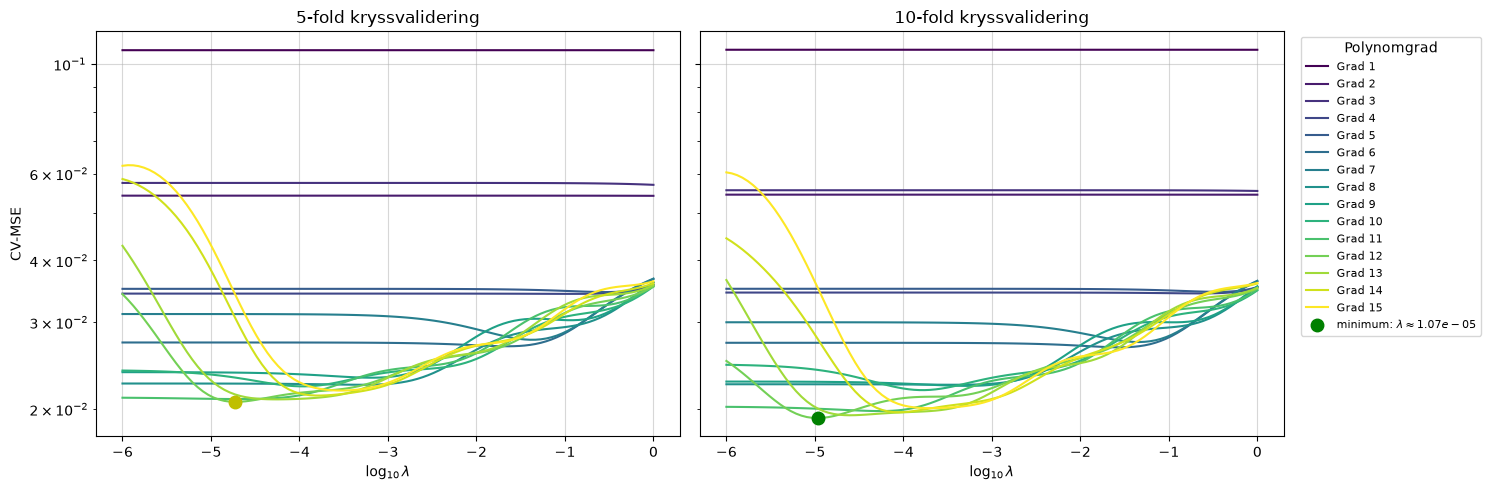

In [56]:
degrees = np.arange(1, 16)
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 1, len(degrees)))
mse_sklearn5, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=5, degree=12)
mse_sklearn10, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=10, degree=12)

best5 = np.argmin(mse_sklearn5)
best10 = np.argmin(mse_sklearn10)

for ax, k in zip(axes, [5, 10]):
    for deg, color in zip(degrees, colors):
        mse, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=k, degree=deg)
        ax.plot(np.log10(lambdas), mse,color=color, lw=1.5, label=f"Grad {deg}")

    #ax.axhline(sigma**2, color="gray", ls=":",label=r"Støyvarians $\sigma^2$")
    ax.set_title(f"{k}-fold kryssvalidering")
    ax.set_xlabel(r"$\log_{10}\lambda$")
    ax.set_yscale("log")
    ax.grid(alpha=0.5)

axes[0].plot(np.log10(lambdas[best5]), mse_sklearn5[best5], "o", color='y', ms=9,label=rf"minimum: $\lambda\approx{lambdas[best5]:.3g}$")
axes[1].plot(np.log10(lambdas[best10]), mse_sklearn10[best10], "o", color='green', ms=9,label=rf"minimum: $\lambda\approx{lambdas[best10]:.3g}$")

axes[0].set_ylabel("CV-MSE")
axes[1].legend(title="Polynomgrad", bbox_to_anchor=(1.02, 1),loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [450]:
rng = np.random.default_rng(2026)
sigma = 0.1
n = 100
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma, size = n)   

lambdas = np.logspace(-6, 0, n)
degrees = np.arange(1, 16)
nlam = len(lambdas)

cv5_best_mse = []
cv10_best_mse = []
cv5_best_lambda = []
cv10_best_lambda = []

for d in degrees:
    mse5, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=5, degree=d)
    mse10, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=10, degree=d)
    i5 = np.argmin(mse5)
    i10 = np.argmin(mse10)
    cv5_best_mse.append(mse5[i5])
    cv10_best_mse.append(mse10[i10])
    cv5_best_lambda.append(lambdas[i5])
    cv10_best_lambda.append(lambdas[i10])

In [188]:
bootstrap_best = (table_lambda.loc[table_lambda.groupby("Degree")["Error"].idxmin()].sort_values("Degree"))

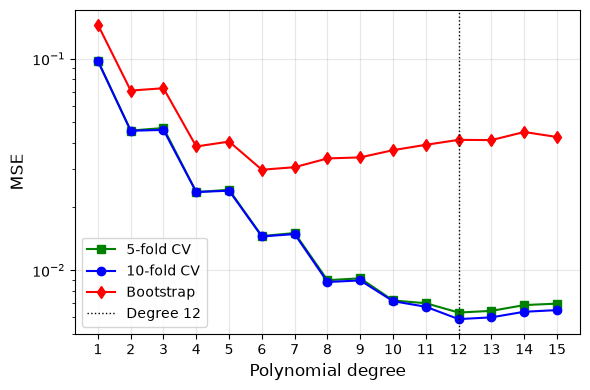

In [421]:
fig, ax = plt.subplots(figsize=(6.0, 4.0))
i5 = np.argmin(cv5_best_mse)
#i10 = np.argmin(cv10_best_mse)
#best_boot = bootstrap_best.loc[bootstrap_best["Error"].idxmin()]
ax.plot(degrees, cv5_best_mse, "s-", color = "green", label=rf"5-fold CV")
ax.plot(degrees, cv10_best_mse, "o-", color = "blue", label=rf"10-fold CV")
ax.plot(bootstrap_best["Degree"],bootstrap_best["Error"],"d-", color="red",label="Bootstrap")
#ax.plot(bootstrap_best, bootstrap_best, "d-", color="red", label=rf"Bootstrap, lambda = {best_boot['Error']:.4f}")


best_degree = degrees[i5]
best_mse = cv5_best_mse[i5]

ax.axvline(best_degree, color="k", ls=":", lw=1,label=f"Degree {best_degree}")
#ax.axhline(best_mse, color="k", ls="--", lw=1,label=f"5-fold CV: MSE {best_mse:.4f}")

ax.set_xlabel("Polynomial degree", fontsize=12)
ax.set_ylabel("MSE", fontsize=12)
ax.set_xticks(degrees)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [451]:
# Sett sigma til støynivået som disse CV-resultatene gjelder.
sigma = 0.1

for name, mse_values, lambda_values in [("5-fold CV", cv5_best_mse, cv5_best_lambda),("10-fold CV", cv10_best_mse, cv10_best_lambda)]:
    idx = int(np.argmin(mse_values))
    add_result("Ridge", sigma, name,degrees[idx], mse_values[idx], lambda_values[idx])

CV for sigma = 0.05 for ridge

In [452]:
rng = np.random.default_rng(2026)
sigma = 0.05
n = 100
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma, size = n)   

lambdas = np.logspace(-6, 0, n)
degrees = np.arange(1, 16)
nlam = len(lambdas)

cv5_best_mse = []
cv10_best_mse = []
cv5_best_lambda = []
cv10_best_lambda = []

for d in degrees:
    mse5, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=5, degree=d)
    mse10, _ = RIDGE_k_fold(x, y, nlam, lambdas, k=10, degree=d)

    i5 = np.argmin(mse5)
    i10 = np.argmin(mse10)

    cv5_best_mse.append(mse5[i5])
    cv10_best_mse.append(mse10[i10])
    cv5_best_lambda.append(lambdas[i5])
    
    cv10_best_lambda.append(lambdas[i10])

bootstrap_best2 = (table_lambda2.loc[table_lambda2.groupby("Degree")["Error"].idxmin()].sort_values("Degree"))

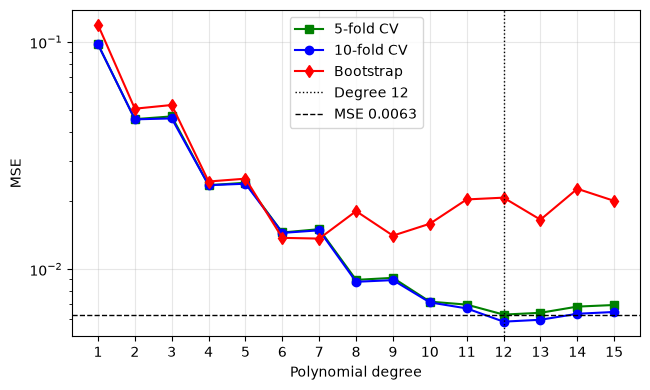

In [ ]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
i5 = np.argmin(cv5_best_mse)

ax.plot(degrees, cv5_best_mse, "s-", color = "green", label=rf"5-fold CV")
ax.plot(degrees, cv10_best_mse, "o-", color = "blue", label=rf"10-fold CV")
ax.plot(bootstrap_best2["Degree"],bootstrap_best2["Error"],"d-", color="red",label="Bootstrap")

best_degree = degrees[i5]
best_mse = cv5_best_mse[i5]

ax.axvline(best_degree, color = "k", ls=":", lw=1,label=f"Degree {best_degree}")
ax.axhline(best_mse, ls="--", color = "k",lw=1,label=f"MSE {best_mse:.4f}")
#ax.plot(bootstrap_best, bootstrap_best, "d-", color="red", label=rf"Bootstrap, lambda = {best_boot['Error']:.4f}")

ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE")
ax.set_xticks(degrees)
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [453]:
# Sett sigma til støynivået som disse CV-resultatene gjelder.
sigma = 0.05

for name, mse_values, lambda_values in [("5-fold CV", cv5_best_mse, cv5_best_lambda),("10-fold CV", cv10_best_mse, cv10_best_lambda)]:
    idx = int(np.argmin(mse_values))
    add_result("Ridge", sigma, name,degrees[idx], mse_values[idx], lambda_values[idx])

In [454]:
summary_table = (pd.DataFrame(summary_rows)
    .sort_values(["Model", "Resampling", "Sigma"])
    .reset_index(drop=True))

display(summary_table.style.format({
    "Sigma": "{:.2f}",
    "Lambda": "{:.3e}",
    "MSE": "{:.5f}"}, na_rep="–").hide(axis="index"))

Model,Sigma,Resampling,Degree,Lambda,MSE
OLS,0.05,10-fold CV,14,–,0.00746
OLS,0.10,10-fold CV,11,–,0.02024
OLS,0.05,5-fold CV,14,–,0.00687
OLS,0.10,5-fold CV,11,–,0.02111
OLS,0.05,Bootstrap,6,–,0.01909
OLS,0.10,Bootstrap,6,–,0.03534
Ridge,0.05,10-fold CV,12,6.136e-06,0.00587
Ridge,0.10,10-fold CV,12,1.072e-05,0.01918
Ridge,0.05,5-fold CV,12,8.111e-06,0.00630
Ridge,0.10,5-fold CV,12,1.874e-05,0.02068


In [ ]:
summary_table = (
    pd.DataFrame(summary_rows)
    .drop_duplicates(
        subset=["Model", "Sigma", "Resampling"], keep="last"
    )
    .sort_values(["Model", "Resampling", "Sigma"])
    .reset_index(drop=True)
)

print(summary_table.to_latex(
    index=False,
    escape=False,
    na_rep="--",
    column_format="ll lrrr".replace(" ", ""),
    formatters={
        "Sigma": lambda x: f"{x:.2f}",
        "Lambda": lambda x: f"{x:.3e}",
        "MSE": lambda x: f"{x:.5f}"
    },
    header=[
        "Model", r"$\sigma$", "Resampling",
        "Degree", r"$\lambda$", "MSE"
    ],
    caption=(
        "Selected polynomial degrees, regularization parameters, "
        "and minimum estimated MSE for OLS and Ridge at two noise levels."
    ),
    label="tab:noise_comparison"))

\begin{table}
\caption{Selected polynomial degrees, regularization parameters, and minimum estimated MSE for OLS and Ridge at two noise levels.}
\label{tab:noise_comparison}
\begin{tabular}{lllrrr}
\toprule
Model & $\sigma$ & Resampling & Degree & $\lambda$ & MSE \\
\midrule
OLS & 0.05 & 10-fold CV & 14 & -- & 0.00746 \\
OLS & 0.10 & 10-fold CV & 11 & -- & 0.02024 \\
OLS & 0.05 & 5-fold CV & 14 & -- & 0.00687 \\
OLS & 0.10 & 5-fold CV & 11 & -- & 0.02111 \\
OLS & 0.05 & Bootstrap & 6 & -- & 0.01909 \\
OLS & 0.10 & Bootstrap & 6 & -- & 0.03534 \\
Ridge & 0.05 & 10-fold CV & 12 & 6.136e-06 & 0.00587 \\
Ridge & 0.10 & 10-fold CV & 12 & 1.072e-05 & 0.01918 \\
Ridge & 0.05 & 5-fold CV & 12 & 8.111e-06 & 0.00630 \\
Ridge & 0.10 & 5-fold CV & 12 & 1.874e-05 & 0.02068 \\
Ridge & 0.05 & Bootstrap & 7 & 4.642e-02 & 0.01363 \\
Ridge & 0.10 & Bootstrap & 6 & 4.037e-02 & 0.02987 \\
\bottomrule
\end{tabular}
\end{table}



Exercise E:Writing your own gradient descent code, with analytical gradients
and automatic differentiation
-

In [495]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)
import optax

In [496]:
def closed_form(X, y, lam=0.0):
    """(X^T X + n lambda I)^-1 X^T y, the 1/n convention of Eq. (3.95)."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def cost(theta, X, y, lam=0.0):
    """Eqs. (4.12) and (4.16)."""
    return np.sum((X @ theta - y) ** 2) / len(y) + lam * theta @ theta

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): your analytical gradient from last week (or jax.grad of cost)."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

In [497]:
theta, Xtr_sc, Xte_sc, y_train, y_test = exercisedata(x, y, d=8, sigma=0.1, n=100)

In [498]:
jax.config.update("jax_enable_x64", True)

def cost_jax(theta, X, y, lam=0.0):
    error = X @ theta - y
    return jnp.mean(error**2) + lam * jnp.sum(theta**2)

gradient_jax = jax.grad(cost_jax, argnums=0)
def automatic_gradient(theta, X, y, lam=0.0):
    grad = gradient_jax(jnp.asarray(theta),jnp.asarray(X),jnp.asarray(y),lam)

    return np.asarray(grad)

In [499]:
theta0 = np.zeros(Xtr_sc.shape[1])

# OLS
grad_analytical_ols = gradient(theta0, Xtr_sc, y_train, lam=0.0)
grad_jax_ols = automatic_gradient( theta0, Xtr_sc, y_train, lam=0.0)

print( "Difference between analytical OLS and JAX OLS:",np.max(np.abs(grad_analytical_ols - grad_jax_ols)))

# Ridge
grad_analytical_ridge = gradient(theta0, Xtr_sc, y_train, lam=0.01)
grad_jax_ridge = automatic_gradient(theta0, Xtr_sc, y_train, lam=0.01)

print("Difference between analytical Ridge and JAX Ridge:",np.max(np.abs(grad_analytical_ridge - grad_jax_ridge)))

Difference between analytical OLS and JAX OLS: 1.1102230246251565e-16
Difference between analytical Ridge and JAX Ridge: 1.1102230246251565e-16


Diffrence of -16 is to MP.

In [500]:
def hessian(X, lam =0.0):
    n = X.shape[0]
    I = np.eye(X.shape[1])
    H =  (2/n)*(X.T@X) + 2*lam*I
    return H

def eigenvalues_minmax(X, lam=0.0):
    H = hessian(X, lam =lam)
    
    eigenvalues = np.linalg.eigvals(H)
    lmin = eigenvalues.min()
    lmax = eigenvalues.max()
    
    kappa = lmax/lmin
    gamma_opt = 2/(lmin + lmax)
    
    
    return lmin, lmax, kappa, gamma_opt

def grad_decent(X,y,gamma, grad_func,lam=0.0,num_iters=10000,tol=1e-6):
    X = np.asarray(X)
    y = np.asarray(y).ravel()

    n, p = X.shape
    I = np.eye(p)

    # Startverdi
    theta_gd = np.zeros(p)

    grad_length = []
    difference = []

    # Lukket løsning
    if lam == 0:
        # lstsq er tryggere enn solve dersom X.T @ X er singulær
        theta_closed = np.linalg.lstsq(X, y, rcond=None)[0]
    else:
        theta_closed = np.linalg.solve( X.T @ X + n * lam * I, X.T @ y)
    # Standardverdi dersom metoden ikke konvergerer
    iterations = num_iters

    for t in range(num_iters):

        # Gradient beregnet med funksjonen vi sender inn
        grad = np.asarray(grad_func(theta_gd, X, y, lam))

        # Oppdater parameterne
        theta_gd = theta_gd - gamma * grad

        # Mål etter oppdateringen
        grad_l = np.linalg.norm(grad_func(theta_gd, X, y, lam))
        diff = np.linalg.norm(theta_gd - theta_closed)

        grad_length.append(grad_l)
        difference.append(diff)

        # Samme stoppkriterium for OLS og Ridge
        if grad_l < tol and diff < tol:
            iterations = t + 1
            print(f"gamma = {gamma}: "f"Konvergerte etter {t + 1} iterasjoner")
            break

    else:
        print(f"gamma = {gamma}: "f"Konvergerte ikke etter {num_iters} iterasjoner")

    return theta_gd, theta_closed, difference, grad_length, iterations

In [ ]:
rows = []
for lam in [0.0, 0.01]:
    print("\nAnalytical OLS" if lam == 0 else "\nAnalytical Ridge")
    lmin, lmax, kappa, gamma_opt = (eigenvalues_minmax(Xtr_sc, lam=lam))
    theta_gd, theta_closed, difference, grad_length, iterations = (grad_decent(Xtr_sc,y_train,gamma=gamma_opt,grad_func=gradient,lam=lam))
    rows.append({"Method": "OLS" if lam == 0 else "Ridge",lambda": lam,
        "lambda_min": lmin,
        "lambda_max": lmax,
        "kappa": kappa,
        "gamma_opt": gamma_opt,
        "Iteration": iterations,
        "Diffrence": difference[-1]
    })

table_gd = pd.DataFrame(rows)

display(table_gd.style.format({
    "lambda": "{:.1f}",
    r"lambda_min": "{:.3g}",
    r"\lambda_max": "{:.3g}",
    r"\kappa": "{:.3g}",
    r"\gamma_{opt}": "{:.3g}",
    "Difference": "{:.3g}"
}))


Analytical OLS
gamma = 0.22980274127796466: Konvergerte ikke etter 10000 iterasjoner

Analytical Ridge
gamma = 0.2287513873602343: Konvergerte etter 2836 iterasjoner


,Method,$\lambda$,lambda_min,lambda_max,kappa,gamma_opt,Iteration,Diffrence
0,OLS,0.000000,0.000111,8.703005,78412.154390,0.229803,10000,8.977764
1,Ridge,0.010000,0.0201,8.723005,433.743200,0.228751,2836,0.000000


In [55]:
rows = []
for lam in [0.0, 0.01]:
    print("\nAutomatic OLS" if lam == 0 else "\nAutomatic Ridge")

    lmin, lmax, kappa, gamma_opt = (eigenvalues_minmax(Xtr_sc, lam=lam))
    theta_gd, theta_closed, difference, grad_length, iterations = (grad_decent(Xtr_sc,y_train,gamma=gamma_opt,grad_func=automatic_gradient,lam=lam))
    rows.append({"Method": "OLS" if lam == 0 else "Ridge","lambda": lam,
            "lambda_min": lmin,
            "lambda_max": lmax,
            "kappa": kappa,
            "gamma_opt": gamma_opt,
            "Iteration": iterations,
            "Diffrence": difference[-1]})
    
    
table_gd = pd.DataFrame(rows)

display(table_gd.style.format({
    "lambda": "{:.1f}",
    r"lambda_{min}": "{:.3g}",
    r"lambda_{max}": "{:.3g}",
    r"kappa": "{:.3g}",
    r"gamma_{opt}": "{:.3g}",
    "Difference": "{:.3g}"}))
  


Automatic OLS
gamma = 0.22980274127796466: Konvergerte ikke etter 10000 iterasjoner

Automatic Ridge
gamma = 0.2287513873602343: Konvergerte etter 2836 iterasjoner


,Method,lambda,lambda_min,lambda_max,kappa,gamma_opt,Iteration,Diffrence
0,OLS,0.0,0.000111,8.703005,7.84e+04,0.229803,10000,8.977764
1,Ridge,0.0,0.020111,8.723005,434,0.228751,2836,0.000000


In [501]:
from IPython.display import display, Math

rows = []
#Analytisk
for lam in [0.0, 0.001]:
    method = "OLS" if lam == 0 else "Ridge"
    lmin, lmax, kappa, gamma_opt = eigenvalues_minmax(Xtr_sc, lam=lam)
    gammas = {"Liten": 0.1 * gamma_opt,"Optimal": gamma_opt,"Under grensen": 0.99 * gamma_opt,"Over grensen": 1.02 * gamma_opt,}

    for gamma_name, gamma in gammas.items():
        theta_gd, theta_closed, difference, grad_length, iterations = grad_decent(Xtr_sc, y_train,gamma=gamma,grad_func=gradient,lam=lam)

        rows.append({
            "Method": method,
            "Gamma choice": gamma_name,
            "Lambda": lam,
            "Gamma": gamma,
            "Iterations": iterations,
            "Difference": difference[-1]})

table_gamma = pd.DataFrame(rows)

headers = [r"\text{Method}", r"\text{Gamma choice}", r"\lambda", r"\gamma",r"\text{Iterations}", r"\text{Difference}"]
lines = [r"\begin{array}{llrrrrr}"," & ".join(headers) + r" \\ \hline"]

for row in rows:
    values = [
        rf"\text{{{row['Method']}}}",
        rf"\text{{{row['Gamma choice']}}}",
        f"{row['Lambda']:.2f}",
        f"{row['Gamma']:.3g}",
        str(row["Iterations"]),
        f"{row['Difference']:.3g}",]
    lines.append(" & ".join(values) + r" \\")

lines.append(r"\end{array}")
display(Math("\n".join(lines)))

gamma = 0.022980274127796466: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.22980274127796466: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.227504713865185: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.23439879610352396: Konvergerte ikke etter 10000 iterasjoner


C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\linalg\_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


gamma = 0.022969717119875388: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.22969717119875385: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.22740019948676632: Konvergerte ikke etter 10000 iterasjoner
gamma = 0.23429111462272895: Konvergerte ikke etter 10000 iterasjoner


<IPython.core.display.Math object>

In [ ]:
for lam in [0.0, 0.001]:

    model = "Automatic OLS" if lam == 0 else "Automatic Ridge"
    print(f"\n---------- {model} ----------")

    lmin, lmax, kappa, gamma_opt, = (eigenvalues_minmax(Xtr_sc, lam=lam))

    gammas = {"liten": 0.1 * gamma_opt,"optimal": gamma_opt,"under grensen": 0.99 * gamma_opt,"over grensen": 1.02 * gamma_opt}

    print("lambda_min:", lmin)
    print("lambda_max:", lmax)
    print("kappa:", kappa)
    print("gamma_opt:", gamma_opt)
    print("stabilitetsgrense:", gamma_opt)

    for gamma_name, gamma in gammas.items():

        print(f"\n{gamma_name}, gamma = {gamma}")

        theta_gd, theta_closed, difference, grad_length, iterations = (grad_decent(Xtr_sc,y_train,gamma=gamma,grad_func=automatic_gradient,lam=lam))

        print("Iterasjoner:", iterations)
        print("Sluttforskjell:", difference[-1])
        print("Gradientlengde:", grad_length[-1])


---------- Automatic OLS ----------
lambda_min: 0.00011099051479269746
lambda_max: 8.703005381716995
kappa: 78412.15438969748
gamma_opt: 0.22980274127796466
stabilitetsgrense: 0.22980274127796466

liten, gamma = 0.022980274127796466
gamma = 0.022980274127796466: Konvergerte ikke etter 10000 iterasjoner
Iterasjoner: 10000
Sluttforskjell: 11.326905498021683
Gradientlengde: 0.0022503455825058456

optimal, gamma = 0.22980274127796466
gamma = 0.22980274127796466: Konvergerte ikke etter 10000 iterasjoner
Iterasjoner: 10000
Sluttforskjell: 8.977763950803602
Gradientlengde: 0.36910224234844247

under grensen, gamma = 0.227504713865185
gamma = 0.227504713865185: Konvergerte ikke etter 10000 iterasjoner
Iterasjoner: 10000
Sluttforskjell: 9.000706580203477
Gradientlengde: 0.0010124579954416328

over grensen, gamma = 0.23439879610352396


C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\linalg\_linalg.py:2768: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)


gamma = 0.23439879610352396: Konvergerte ikke etter 10000 iterasjoner
Iterasjoner: 10000
Sluttforskjell: inf
Gradientlengde: inf

---------- Automatic Ridge ----------
lambda_min: 0.20011099051479342
lambda_max: 8.903005381716994
kappa: 44.49033688161585
gamma_opt: 0.21970497994519925
stabilitetsgrense: 0.21970497994519925

liten, gamma = 0.021970497994519927
gamma = 0.021970497994519927: Konvergerte etter 2425 iterasjoner
Iterasjoner: 2425
Sluttforskjell: 9.95872995082823e-07
Gradientlengde: 2.0880680056340324e-07

optimal, gamma = 0.21970497994519925
gamma = 0.21970497994519925: Konvergerte etter 291 iterasjoner
Iterasjoner: 291
Sluttforskjell: 1.3694625525899317e-07
Gradientlengde: 9.903807433010198e-07

under grensen, gamma = 0.21750793014574726
gamma = 0.21750793014574726: Konvergerte etter 240 iterasjoner
Iterasjoner: 240
Sluttforskjell: 9.900106010792061e-07
Gradientlengde: 2.1858894772710975e-07

over grensen, gamma = 0.22409907954410324
gamma = 0.22409907954410324: Konvergerte

In [502]:

rows_auto = []

for lam in [0.0, 0.001]:
    method = "Automatic OLS" if lam == 0 else "Automatic Ridge"
    lmin, lmax, kappa, gamma_opt  = eigenvalues_minmax(Xtr_sc, lam=lam)

    gammas = {"Liten": 0.1 * gamma_opt, "Optimal": gamma_opt,"Under grensen": 0.99 * gamma_opt,"Over grensen": 1.02 * gamma_opt,}

    for gamma_name, gamma in gammas.items():
        theta_gd, theta_closed, difference, grad_length, iterations = grad_decent(Xtr_sc, y_train,gamma=gamma,grad_func=automatic_gradient,lam=lam)

        rows_auto.append({"Method": method,"Gamma choice": gamma_name,"Lambda": lam,"Gamma": gamma,"Iterations": iterations,"Difference": difference[-1]})

table_auto = pd.DataFrame(rows_auto)


KeyboardInterrupt: 

In [74]:

headers = [r"\text{Method}", r"\text{Gamma choice}", r"\lambda", r"\gamma", r"\text{Iterations}", r"\text{Difference}"]
lines = [r"\begin{array}{llrrrrr}", " & ".join(headers) + r" \\ \hline"]

for row in rows_auto:
    values = [rf"\text{{{row['Method']}}}",rf"\text{{{row['Gamma choice']}}}",f"{row['Lambda']:.1f}",f"{row['Gamma']:.3g}",str(row["Iterations"]),f"{row['Difference']:.3g}",]
    lines.append(" & ".join(values) + r" \\")

lines.append(r"\end{array}")
display(Math("\n".join(lines)))

<IPython.core.display.Math object>

F Including momentum and more advanced ways to update the learning rate
-

In [504]:
def runge_data(n=100, degree=8, noise=0.1, seed=2026):

    rng = np.random.default_rng(seed)
    x = rng.uniform(-1.0, 1.0, n)
    y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
    X = np.column_stack([x**k for k in range(1, degree + 1)])
    X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
    return X_norm, y - y.mean()

def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t = 1, 2, ...; state carries the running quantities."""
    if method == "plain":                                    # Eq. (4.10)
        return theta - gamma * g, state
    if method == "momentum":                                 # Eq. (4.28)
        state["v"] = v = beta * state.get("v", 0.0) + gamma * g 
        return theta - v, state
    if method == "adagrad":                                  # Eqs. (4.42) and (4.45)
        state["r"] = r = state.get("r", 0.0) + g * g
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "rmsprop":                                  # Eqs. (4.47) and (4.48)
        state["r"] = r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g 
        return theta - gamma * g / (np.sqrt(r) + eps), state
    if method == "adam":                                     # Eqs. (4.51), (4.52), (4.54), (4.55)
        state["m"] = m =  beta1 * state.get("m", 0.0) + (1.0 - beta1) * g
        state["r"] = r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g
        m_hat, r_hat = m / (1.0 - beta1**t), r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state
    raise ValueError(f"unknown method {method}")

def optimise(grad, theta0, method, gamma, num_iters=1000, tol=1e-8, **kw):
    """Full-gradient loop; returns all iterates and the number of steps taken."""
    theta, state = np.array(theta0, dtype=float), {}
    
    history = [theta.copy()]
    for t in range(1, num_iters + 1):
        with np.errstate(over="ignore", invalid="ignore"):
            g = grad(theta)
        #g = grad(theta)
        if not np.all(np.isfinite(g)):
            break
        theta, state = optimiser_step(method, theta, g, state, t, gamma, **kw)
        if not np.all(np.isfinite(theta)):
            break

        history.append(theta.copy())
        if np.linalg.norm(g) < tol:
            break
    return np.array(history), t


def runge_comparison(runs, degree=10, num_iters=30000, tol_dist = 1e-8):
    """Excess cost C(theta_k) - C(theta_hat) for the five optimisers on the Runge problem."""
    X, y = runge_data(n=100, degree=degree, noise=0.1, seed=2026)#exercise_data(n=100, degree=degree, noise=0.5, seed=2026)    #Finne ut hvordan man skal gjre denne her.. 
    results = {}
    for lam in (0.0, 0.001):
        theta_cf = closed_form(X, y, lam)
        min_cost = cost(theta_cf, X,y,lam)
        grad = lambda theta: gradient(theta, X, y, lam)
        H = hessian(X, lam)
        eigenvalues = np.linalg.eigvalsh(H)
        lmax = eigenvalues.max()
        gamma_gd = 0.9 * 2.0 / lmax
        for method, gamma in runs:
            g = gamma_gd if gamma is None else gamma
            theta0 = np.zeros(X.shape[1])
            #path, steps = optimise(grad, theta0, method, g, num_iters=num_iters)
            path, steps = optimise(grad,theta0,method,g,num_iters=num_iters)
            distances = np.array([np.linalg.norm(theta_k - theta_cf) for theta_k in path])
            costs = np.array([cost(theta_k, X, y, lam)for theta_k in path])
            excess_cost = costs - min_cost
            results[(lam, method, g)] = {"distances": distances,"excess_cost": excess_cost, "final_cost": costs[-1],"steps": steps,"final_distance": distances[-1], "converged": distances[-1] < tol_dist}

    return results

In [ ]:
#Test1. Antall iterasjoner for å nå en viss nøyaktighet.
#the number of iterations needed to reach a given accuracy relative to the closed-form solution,and in terms of their sensitivity to the choice of the (initial) learning rate.

In [509]:
runs = (("momentum", None),("adagrad", 0.001),("adagrad", 0.01),("adagrad", 0.1),("rmsprop", 0.001),("rmsprop", 0.01),("rmsprop", 0.1),("adam", 0.001), ("adam", 0.01), ("adam", 0.1))
results = runge_comparison(runs,degree=10,num_iters=10000, tol_dist = 1e-4)
headers = [r"\lambda", r"\text{Method}", r"\gamma",r"\text{Steps}", r"\text{Distance}", r"\text{Converged}"]
lines = [r"\begin{array}{rlrrrc}"," & ".join(headers) + r" \\ \hline"]

for (lam, method, gamma), result in results.items():
    values = [f"{lam:g}", rf"\text{{{method}}}", f"{gamma:.5f}", str(result["steps"]), f"{result['final_distance']:.3e}",
        r"\text{Yes}" if result["converged"] else r"\text{No}",]
    lines.append(" & ".join(values) + r" \\")

lines.append(r"\end{array}")
display(Math("\n".join(lines)))

<IPython.core.display.Math object>

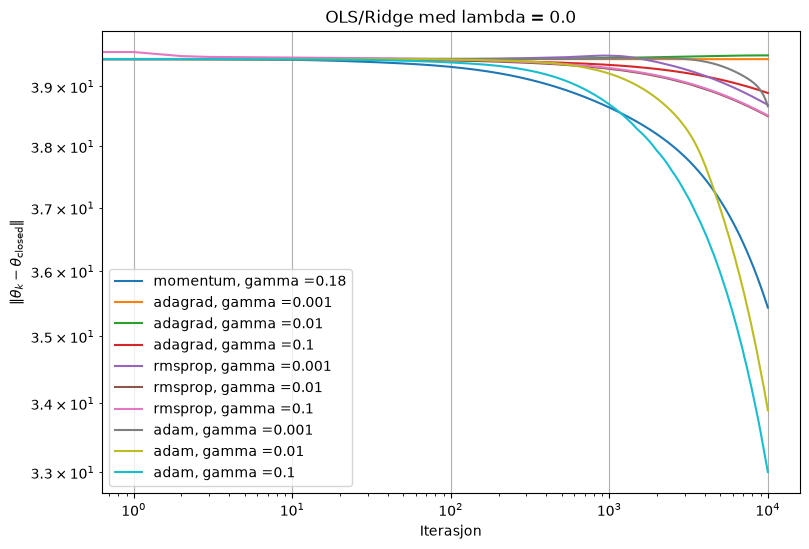

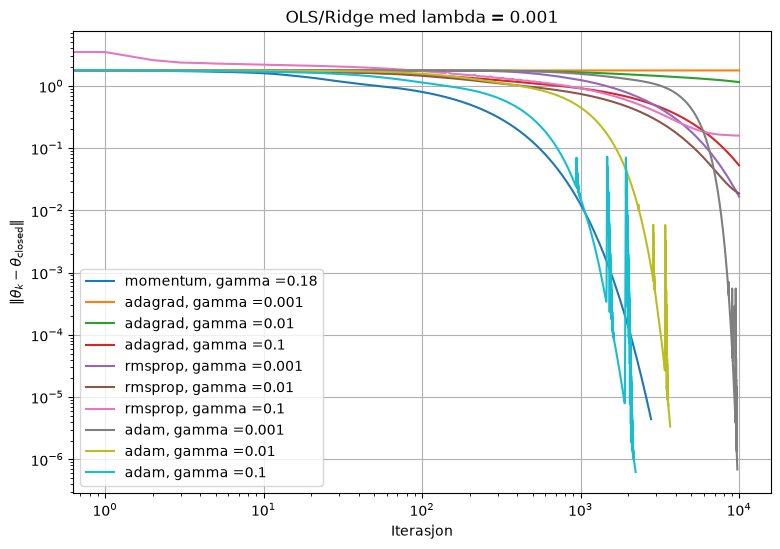

In [510]:

for lam in (0.0, 0.001):
    plt.figure(figsize=(9, 6))

    for (current_lam, method, gamma), result in results.items():
        if current_lam == lam:
            plt.loglog(result["distances"],label=f"{method}, gamma ={gamma:.3g}")

    plt.xlabel("Iterasjon")
    plt.ylabel(r"$\|\theta_k-\theta_{\mathrm{closed}}\|$")
    plt.title(f"OLS/Ridge med lambda = {lam}")
    plt.legend()
    plt.grid(True)
    plt.show()

G Writing our own code for Lasso regression
-

In [517]:
import jax
import jax.numpy as jnp

derivative_at_zero = jax.grad(lambda t: jnp.abs(t))(0.0)

print("AD at zero:", derivative_at_zero)
print("My code at zero:", np.sign(0.0))

AD at zero: 1.0
My code at zero: 0.0


In [518]:
def lasso_gradient(theta, X, y, lam):
    n = len(y)
    mse_grad = (2 / n) * X.T @ (X @ theta - y)
    penalty_grad = lam * np.sign(theta)
    penalty_grad[0] = 0.0       # Ikke straff konstantleddet/interceptet

    return mse_grad + penalty_grad

degrees = 15
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=2026)


y_train = np.asarray(y_train).ravel()
y_test = np.asarray(y_test).ravel()
degree = 10
X_train = design_matrix(x_train, degree)
X_test = design_matrix(x_test, degree)
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc = X_test.copy()
X_train_sc[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_test_sc[:, 1:] = scaler.transform(X_test[:, 1:])


lam = 0.001

grad_lasso = lambda theta: lasso_gradient(theta,X_train_sc,y_train,lam)
theta0 = np.zeros(X_train_sc.shape[1])

methods = ["momentum", "adagrad", "rmsprop", "adam"]


#optimaliseringsmetodene
for method in methods:
    gamma = 0.01


    theta_path, state = optimise(grad=grad_lasso,theta0=theta0.copy(), method=method, gamma=0.01, num_iters=10_000)
    theta_lasso = theta_path[-1]

    # Prediksjoner
    y_pred_train = X_train_sc @ theta_lasso
    y_pred_test = X_test_sc @ theta_lasso

    # MSE
    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse = np.mean((y_test - y_pred_test)**2)
    exact_zero = np.sum(theta_lasso[1:] == 0)
    near_zero = np.sum(np.abs(theta_lasso[1:]) < 1e-4)
    near_zero_degrees = np.where(np.abs(theta_lasso[1:]) < 1e-4)[0] + 1
    print(f"{method:8s}",f"train MSE: {train_mse:.6f}",f"test MSE: {test_mse:.6f}",f"exact zeros: {exact_zero}",f"near zeros: {near_zero}")
    
    #print(f"{method}, gamma={gamma}: "f"exact zeros={exact_zero}, near zeros={near_zero}")
    near_zero_degrees = np.where(np.abs(theta_lasso[1:]) < 1e-4)[0] + 1
    print("Grader med koeffisient nær null:", near_zero_degrees)
    #print("Verdiene:", theta_lasso[near_zero_degrees])
    

momentum train MSE: 0.018765 test MSE: 0.122894 exact zeros: 0 near zeros: 3
Grader med koeffisient nær null: [3 6 7]
adagrad  train MSE: 0.021663 test MSE: 0.083759 exact zeros: 0 near zeros: 1
Grader med koeffisient nær null: [7]
rmsprop  train MSE: 0.021297 test MSE: 0.119395 exact zeros: 0 near zeros: 0
Grader med koeffisient nær null: []
adam     train MSE: 0.018190 test MSE: 0.111709 exact zeros: 0 near zeros: 2
Grader med koeffisient nær null: [ 7 10]


In [519]:
# Samme regulariseringsstyrke som i vår kostnadsfunksjon
alpha = lam / 2

# Vi fjerner konstantkolonnen fordi sklearn lager intercept selv
lasso_sklearn = Lasso( alpha=alpha, fit_intercept=True, max_iter=100_000, tol=1e-10)
lasso_sklearn.fit(X_train_sc[:, 1:],y_train)

# Samle intercept og koeffisienter i én theta-vektor
theta_sklearn = np.concatenate(([lasso_sklearn.intercept_],lasso_sklearn.coef_))
# Prediksjoner fra sklearn
y_pred_sklearn_train = lasso_sklearn.predict(X_train_sc[:, 1:])
y_pred_sklearn_test = lasso_sklearn.predict(X_test_sc[:, 1:])
# MSE
mse_sklearn_train = np.mean((y_train - y_pred_sklearn_train)**2)
mse_sklearn_test = np.mean((y_test - y_pred_sklearn_test)**2)
# Sammenlign med egen løsning
print("Egen theta:")
print(theta_lasso)

print("\nSklearn theta:")
print(theta_sklearn)

print("\nAvstand mellom koeffisientene:", np.linalg.norm(theta_lasso - theta_sklearn))
print("Sklearn train MSE:", mse_sklearn_train)
print("Sklearn test MSE:", mse_sklearn_test)
print("Adam test MSE", test_mse)
print("Adam train MSE", train_mse)

print( "Antall nuller i sklearn:", np.sum(theta_sklearn[1:] == 0))
print("Grader med eksakt null i sklearn:",np.flatnonzero(theta_sklearn[1:] == 0) + 1)

Egen theta:
[ 3.63065115e-01 -6.93826938e-03 -1.07989324e+00 -1.83802314e-04
  1.52529532e+00  2.20222541e-01 -1.12959889e-04 -6.85498241e-05
 -7.98135217e-01 -3.50593077e-01  7.03256393e-05]

Sklearn theta:
[ 0.36306511 -0.00744608 -1.07984975  0.          1.52554764  0.22118753
 -0.          0.         -0.79904096 -0.35086282 -0.        ]

Avstand mellom koeffisientene: 0.0014845683829213814
Sklearn train MSE: 0.018185841409972304
Sklearn test MSE: 0.111693037655915
Adam test MSE 0.11170926127198579
Adam train MSE 0.01819002163025242
Antall nuller i sklearn: 4
Grader med eksakt null i sklearn: [ 3  6  7 10]


In [520]:
def lasso_cost(theta):
    return (np.mean((y_train - X_train_sc @ theta)**2)+ lam * np.sum(np.abs(theta[1:])))

print("Adam Lasso cost:", lasso_cost(theta_lasso))
print("Sklearn Lasso cost:", lasso_cost(theta_sklearn))

Adam Lasso cost: 0.022171534927552916
Sklearn Lasso cost: 0.022169776185669544


In [521]:
lam = 0.001
grad_lasso = lambda theta: lasso_gradient(theta,X_train_sc,y_train,lam)
theta0 = np.zeros(X_train_sc.shape[1])

methods = ["momentum", "adagrad", "rmsprop", "adam"]
gammas = [0.0001, 0.001, 0.01, 0.1]

results = {}

for method in methods:
    results[method] = {}

    for gamma in gammas:

        theta_path, state = optimise(grad=grad_lasso,theta0=theta0.copy(),method=method,gamma=gamma,num_iters=10_000)

        theta_lasso = theta_path[-1]

        # Kontroller om metoden divergerte
        if not np.all(np.isfinite(theta_lasso)):
            results[method][gamma] = {"train_mse": np.nan,"test_mse": np.nan,"near_zero": 0,"diverged": True}

            print(f"{method:8s}, gamma={gamma}: divergerte")
            continue

        # Prediksjoner
        y_pred_train = X_train_sc @ theta_lasso
        y_pred_test = X_test_sc @ theta_lasso

        # MSE
        train_mse = np.mean((y_train - y_pred_train)**2)

        test_mse = np.mean((y_test - y_pred_test)**2)

        coefficients = theta_lasso[1:]

        results[method][gamma] = {
            "train_mse": train_mse,
            "test_mse": test_mse,
            "cost": train_mse + lam * np.sum(np.abs(coefficients)),
            "exact_zero": np.sum(coefficients == 0),
            "near_zero": np.sum(np.abs(coefficients) < 1e-4),
            "diverged": False,
            "theta": theta_lasso.copy()}

In [522]:

rows = []

for method, gamma_results in results.items():
    for gamma, result in gamma_results.items():
        if result["diverged"]:
            continue

        rows.append({
            "Optimizer": method,
            "Gamma": gamma,
            "Test MSE": result["test_mse"],
            "Lasso cost": result["cost"],
            "Exact zeros": result["exact_zero"],
            "Near zeros": result["near_zero"] })

table = (pd.DataFrame(rows).sort_values("Test MSE").reset_index(drop=True))

print("Alle kombinasjoner, sortert etter test-MSE:")
display(table.round(6))

# Første rad for hver optimizer har dens laveste test-MSE
best_per_optimizer = table.drop_duplicates("Optimizer")

print("\nBeste læringsrate for hver optimizer:")
#display(best_per_optimizer.round(5))

# Velg kombinasjonen med lavest test-MSE
best = table.iloc[0]
best_method = best["Optimizer"]
best_gamma = float(best["Gamma"])

theta_best = results[best_method][best_gamma]["theta"].copy()

print(f"\nLavest test-MSE: {best_method}, gamma={best_gamma:g}")
print(f"Test MSE: {best['Test MSE']:.8f}")
print(f"Lasso cost: {best['Lasso cost']:.8f}")

Alle kombinasjoner, sortert etter test-MSE:


,Optimizer,Gamma,Test MSE,Lasso cost,Exact zeros,Near zeros
0,momentum,0.0001,0.055567,0.032259,0,0
1,momentum,0.0010,0.057708,0.024573,0,1
2,adam,0.0001,0.062092,0.025762,0,1
3,adagrad,0.0100,0.083759,0.024263,0,1
4,adam,0.1000,0.110891,0.022171,0,1
5,adam,0.0100,0.111709,0.022172,0,2
6,adam,0.0010,0.111731,0.022170,0,1
7,rmsprop,0.0001,0.111752,0.023882,0,1
8,momentum,0.1000,0.111861,0.022170,0,2
9,adagrad,0.1000,0.118338,0.022349,0,2



Beste læringsrate for hver optimizer:

Lavest test-MSE: momentum, gamma=0.0001
Test MSE: 0.05556676
Lasso cost: 0.03225949


In [523]:
best_cost = table.sort_values("Lasso cost").iloc[0]
best_methodL = best_cost["Optimizer"]
best_gammaL = float(best_cost["Gamma"])
theta_bestL = results[best_methodL][best_gammaL]["theta"].copy()

print("Valgt optimizer:", best_methodL)
print("Gamma:", best_gammaL)

Valgt optimizer: adam
Gamma: 0.001


In [524]:
# Velg Adam-kjøringen med lavest Lasso-kostnad
best_adam = (
    table[table["Optimizer"] == "adam"]
    .sort_values("Lasso cost")
    .iloc[0]
)

gamma_adam = float(best_adam["Gamma"])
theta_adam = results["adam"][gamma_adam]["theta"].copy()

# Scikit-learn med samme regulariseringsstyrke
alpha = lam / 2

lasso_sklearn = Lasso(
    alpha=alpha,
    fit_intercept=True,
    max_iter=100_000,
    tol=1e-10
)
lasso_sklearn.fit(X_train_sc[:, 1:], y_train)

theta_sklearn = np.concatenate(
    ([lasso_sklearn.intercept_], lasso_sklearn.coef_)
)

# Prediksjoner og MSE
y_pred_sklearn_train = lasso_sklearn.predict(X_train_sc[:, 1:])
y_pred_sklearn_test = lasso_sklearn.predict(X_test_sc[:, 1:])

mse_sklearn_train = np.mean((y_train - y_pred_sklearn_train)**2)
mse_sklearn_test = np.mean((y_test - y_pred_sklearn_test)**2)

# Sammenligning
print("Adam gamma:", gamma_adam)

print("\nAdam theta:")
print(theta_adam)

print("\nSklearn theta:")
print(theta_sklearn)

print("\nAvstand mellom koeffisientene:",
      np.linalg.norm(theta_adam - theta_sklearn))

print("\nAdam train MSE:", results["adam"][gamma_adam]["train_mse"])
print("Sklearn train MSE:", mse_sklearn_train)
print("Adam test MSE:", best_adam["Test MSE"])
print("Sklearn test MSE:", mse_sklearn_test)

print("\nAdam Lasso cost:", lasso_cost(theta_adam))
print("Sklearn Lasso cost:", lasso_cost(theta_sklearn))

print("\nAntall eksakte nuller i Adam:",
      np.sum(theta_adam[1:] == 0))
print("Antall eksakte nuller i sklearn:",
      np.sum(theta_sklearn[1:] == 0))

print("\nGrader med eksakt null i Adam:",
      np.flatnonzero(theta_adam[1:] == 0) + 1)
print("Grader med eksakt null i sklearn:",
      np.flatnonzero(theta_sklearn[1:] == 0) + 1)

Adam gamma: 0.001

Adam theta:
[ 3.63065115e-01 -7.48485301e-03 -1.07991123e+00  1.54224152e-04
  1.52552023e+00  2.20888956e-01 -4.78528286e-04  3.70001005e-05
 -7.98490364e-01 -3.50717392e-01 -1.31107252e-04]

Sklearn theta:
[ 0.36306511 -0.00744608 -1.07984975  0.          1.52554764  0.22118753
 -0.          0.         -0.79904096 -0.35086282 -0.        ]

Avstand mellom koeffisientene: 0.0008311513810444787

Adam train MSE: 0.018186264702305655
Sklearn train MSE: 0.018185841409972304
Adam test MSE: 0.11173132103994747
Sklearn test MSE: 0.111693037655915

Adam Lasso cost: 0.022170078592244687
Sklearn Lasso cost: 0.022169776185669544

Antall eksakte nuller i Adam: 0
Antall eksakte nuller i sklearn: 4

Grader med eksakt null i Adam: []
Grader med eksakt null i sklearn: [ 3  6  7 10]


In [525]:
lam_ridge = 0.01
lam_lasso = 0.01

gamma = 0.001
method = "adam"
num_iters = 10_000

theta0 = np.zeros(X_train_sc.shape[1])

gradient_functions = {
    "OLS": lambda theta: gradient(theta, X_train_sc, y_train, lam=0.0),
    "Ridge": lambda theta: gradient(theta, X_train_sc, y_train, lam=lam_ridge),
    "Lasso": lambda theta: lasso_gradient(theta, X_train_sc, y_train, lam=lam_lasso)}

results_models = {}

for model_name, grad_function in gradient_functions.items():

    theta_path, state = optimise(grad=grad_function,theta0=theta0.copy(),method=method,gamma=gamma,num_iters=num_iters)
    theta = theta_path[-1]

    y_pred_train = X_train_sc @ theta
    y_pred_test = X_test_sc @ theta

    train_mse = np.mean((y_train - y_pred_train)**2)
    test_mse = np.mean((y_test - y_pred_test)**2)

    results_models[model_name] = {"theta": theta,"theta_path": theta_path,"train_mse": train_mse,"test_mse": test_mse}
    print(f"{model_name:6s}",f"train MSE = {train_mse:.6f}",f"test MSE = {test_mse:.6f}",f"||theta||₁ = {np.sum(np.abs(theta[1:])):.4f}",f"||theta||₂ = {np.linalg.norm(theta[1:]):.4f}",f"near zero = {np.sum(np.abs(theta[1:]) < 1e-4)}")

OLS    train MSE = 0.016418 test MSE = 0.130380 ||theta||₁ = 9.1717 ||theta||₂ = 3.9672 near zero = 0
Ridge  train MSE = 0.026011 test MSE = 0.052500 ||theta||₁ = 1.4246 ||theta||₂ = 0.6784 near zero = 0
Lasso  train MSE = 0.028170 test MSE = 0.048224 ||theta||₁ = 0.8390 ||theta||₂ = 0.5951 near zero = 2


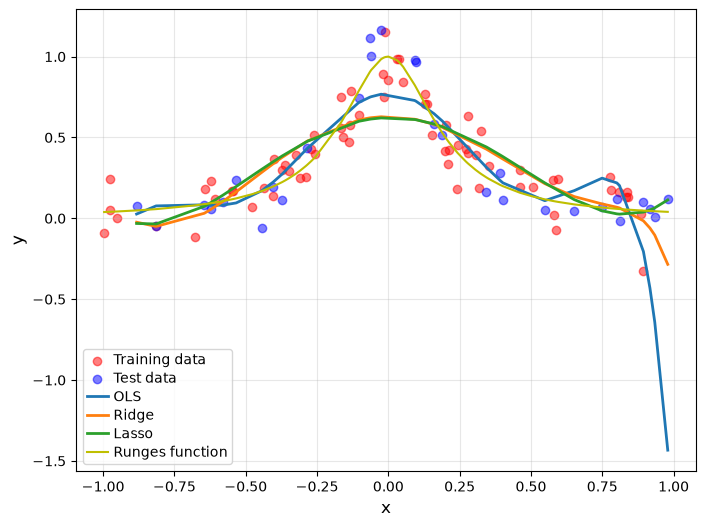

In [540]:
sort_idx = np.argsort(np.asarray(x_test).ravel())
x_test_sorted = np.asarray(x_test).ravel()[sort_idx]
y_test_sorted = np.asarray(y_test).ravel()[sort_idx]

plt.figure(figsize=(8, 6))
plt.scatter(x_train,y_train,alpha=0.5, color = "r",label="Training data")
plt.scatter(x_test,y_test,alpha=0.5,color = "b", label="Test data")
for model_name, result in results_models.items():
    y_pred_sorted = (X_test_sc @ result["theta"])[sort_idx]
    plt.plot(x_test_sorted,y_pred_sorted,linewidth=2,label=model_name)
plt.plot(x,runge(x), color = "y", label = "Runges function")
plt.xlabel("x", fontsize = 12)
plt.ylabel("y", fontsize = 12)
plt.legend(loc="lower left",fontsize=10,borderpad=0.3,labelspacing=0.3,handlelength=1.5,handletextpad=0.4)


plt.grid(alpha=0.3)
plt.show()

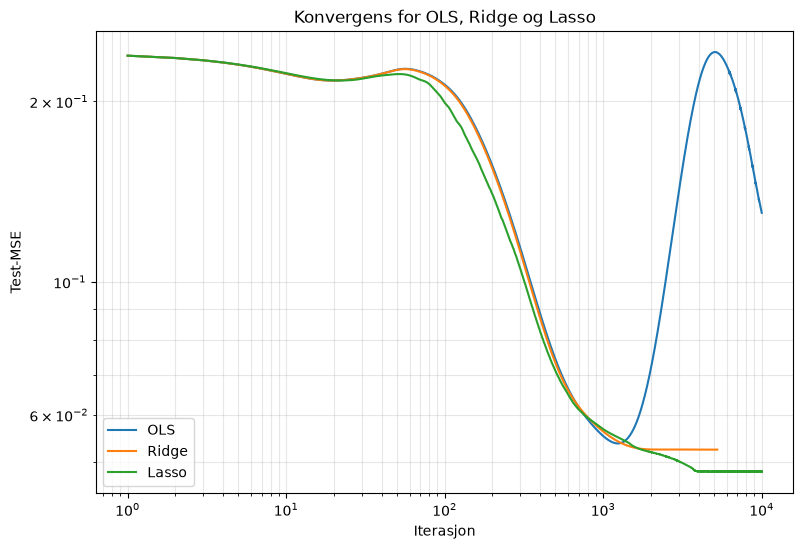

In [541]:
plt.figure(figsize=(9, 6))

for model_name, result in results_models.items():

    theta_path = np.asarray(result["theta_path"])
    test_mse_history = []

    for theta in theta_path:
        y_pred_test = X_test_sc @ theta
        mse = np.mean((y_test - y_pred_test)**2)
        test_mse_history.append(mse)

    iterations = np.arange(1, len(theta_path) + 1)
    plt.loglog(iterations,test_mse_history,label=model_name)

plt.xlabel("Iterasjon")
plt.ylabel("Test-MSE")
plt.title("Konvergens for OLS, Ridge og Lasso")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

H Stochastic gradient descent
-

In [64]:
runs = (("momentum", None),("adagrad", 0.001),("adagrad", 0.01),("adagrad", 0.1),("rmsprop", 0.001),("rmsprop", 0.01),("rmsprop", 0.1),("adam", 0.001), ("adam", 0.01), ("adam", 0.1))

In [12]:
rng = np.random.default_rng(2026)
def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The schedule of Eq. (4.40)."""
    return t0/(t + t1)

def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None, lam=0.0, seed=2026, **kw):
    """Minibatch SGD, Eq. (4.34), with any optimiser. schedule=(t0, t1) replaces gamma by Eq. (4.40).
    Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta, state, t = np.zeros(p), {}, 0
    history = [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)                                   # the gradient of the cost on this minibatch
            gamma_t = gamma if schedule is None else step_length(t-1, *schedule)                             # constant, or the schedule
            theta, state = optimiser_step(method, theta, g, state, t, gamma_t, **kw)
        history.append(theta.copy())
    return np.array(history)


X, y = Xtr_sc, y_train
n = len(y)
theta_cf = closed_form(X, y)
theta = np.zeros(X.shape[1])
g_full = gradient(theta, X, y)
print("full gradient:", g_full)


full gradient: [-0.72613023 -0.0137018   0.41619973 -0.01721887  0.33118812 -0.03542478
  0.28535847 -0.05546648  0.25551654 -0.07371108  0.23365979 -0.08917786
  0.21676724 -0.10181065  0.20342778 -0.1119028 ]


In [66]:
import pandas as pd
rows = []

for M in (1, 5, 25, 70):
    gs = np.array([gradient(theta, X[b], y[b])for _ in range(40)for b in make_batches(n, M, rng)])
    spread = np.std(gs, axis=0).mean()
    rows.append({"Batch size": M,"Mean gradient": np.array2string(gs.mean(axis=0), precision=3, suppress_small=True),"Gradient spread": spread,"Spread × √M": spread * np.sqrt(M),})

gradient_table = pd.DataFrame(rows)
display(gradient_table.style.format({"Gradient spread": "{:.3f}","Spread × √M": "{:.3f}",}).hide(axis="index"))
print("Full gradient:", np.round(g_full, 3))
print("Distance to full gradient", np.linalg.norm(gs.mean(axis=0) - g_full))

Batch size,Mean gradient,Gradient spread,Spread × √M
1,[-0.726 -0.014 0.416 -0.017 0.331 -0.035 0.285 -0.055 0.256 -0.074 0.234 -0.089],0.402,0.402
5,[-0.726 -0.014 0.416 -0.017 0.331 -0.035 0.285 -0.055 0.256 -0.074 0.234 -0.089],0.179,0.400
25,[-0.725 -0.014 0.415 -0.017 0.33 -0.035 0.285 -0.055 0.255 -0.074 0.233 -0.089],0.072,0.361
70,[-0.726 -0.014 0.416 -0.017 0.331 -0.035 0.285 -0.055 0.256 -0.074 0.234 -0.089],0.000,0.000


Full gradient: [-0.726 -0.014  0.416 -0.017  0.331 -0.035  0.285 -0.055  0.256 -0.074
  0.234 -0.089]
Distance to full gradient 5.570623587668902e-16


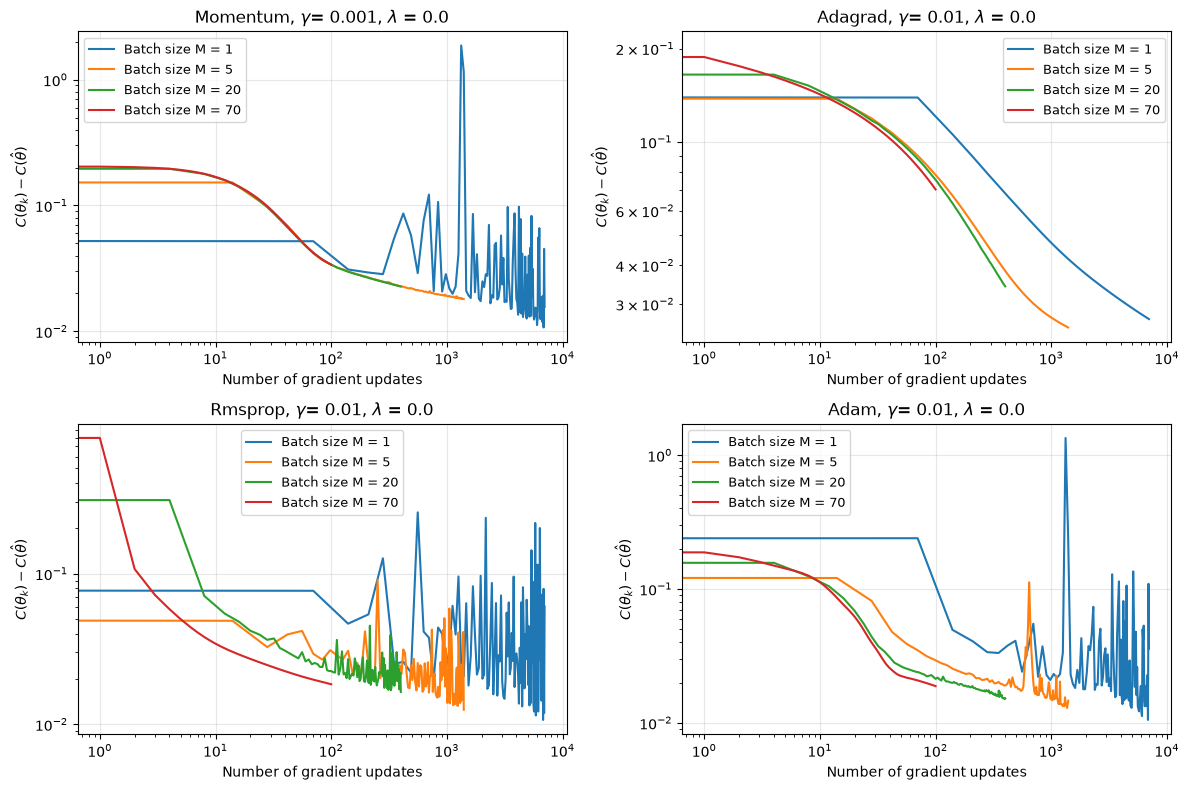

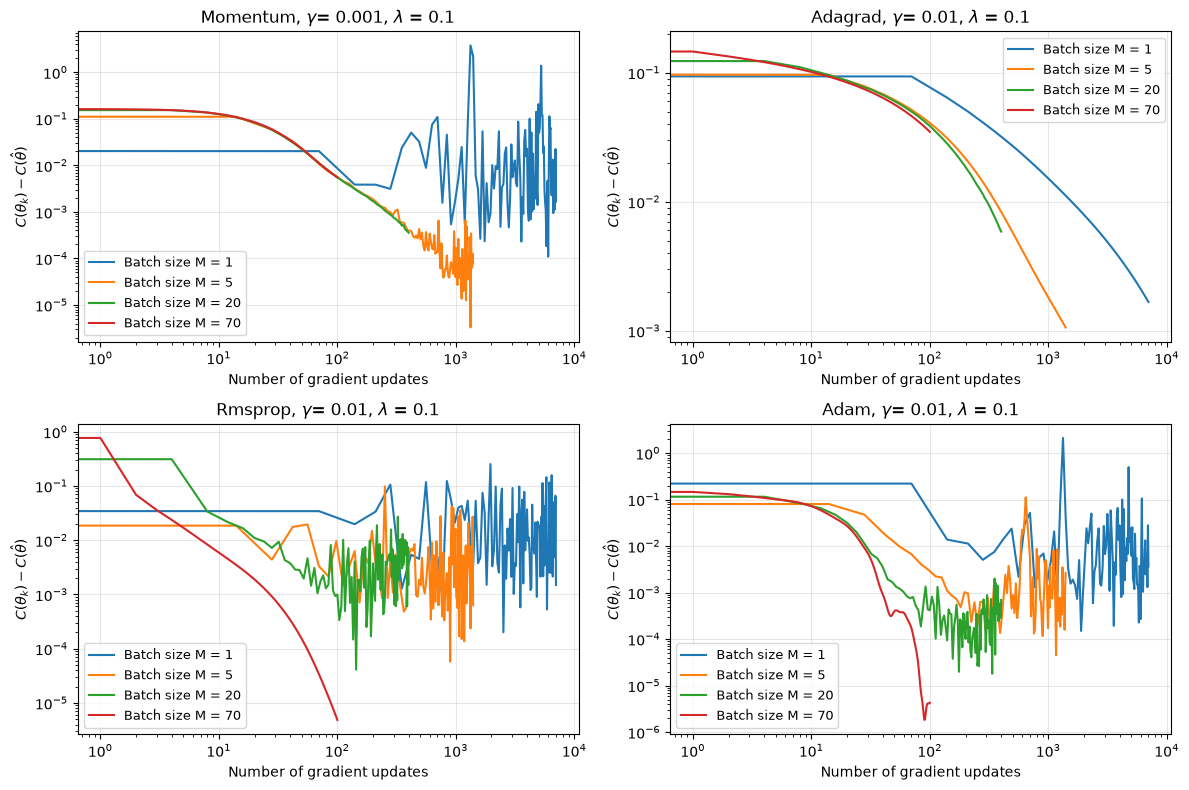

In [67]:
rng = np.random.default_rng(2026)
X, y = Xtr_sc, y_train

n_epochs = 100
batch_sizes = [1, 5, 20, len(y)]
for lam in (0.0, 0.1):
    theta_cf = closed_form(X, y, lam)
    optimal_cost = cost(theta_cf, X, y, lam)

    # Bruk steglengder du har funnet stabile for hver metode.
    gammas = {"momentum": 0.001,"adagrad": 0.01,"rmsprop": 0.01,"adam": 0.01,}

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    for ax, (method, gamma) in zip(axes.flat, gammas.items()):
        for M in batch_sizes:
            hist = sgd(X, y,method=method,n_epochs=n_epochs,batch_size=M,gamma=gamma,lam=lam,seed=2026,)

            excess_cost = np.array([cost(theta, X, y, lam) - optimal_cost for theta in hist])

            updates = np.arange(len(hist)) * int(np.ceil(len(y) / M))
            ax.loglog(updates, excess_cost, label=f"Batch size M = {M}")

        ax.set_title(f"{method.capitalize()}, $\gamma$= {gamma}, $\lambda$ = {lam}")
    
        ax.set_xlabel("Number of gradient updates")
        ax.set_ylabel(r"$C(\theta_k)-C(\hat{\theta})$")
        ax.grid(alpha=0.3)
        ax.legend(fontsize = 9)

    plt.tight_layout()
    plt.show()

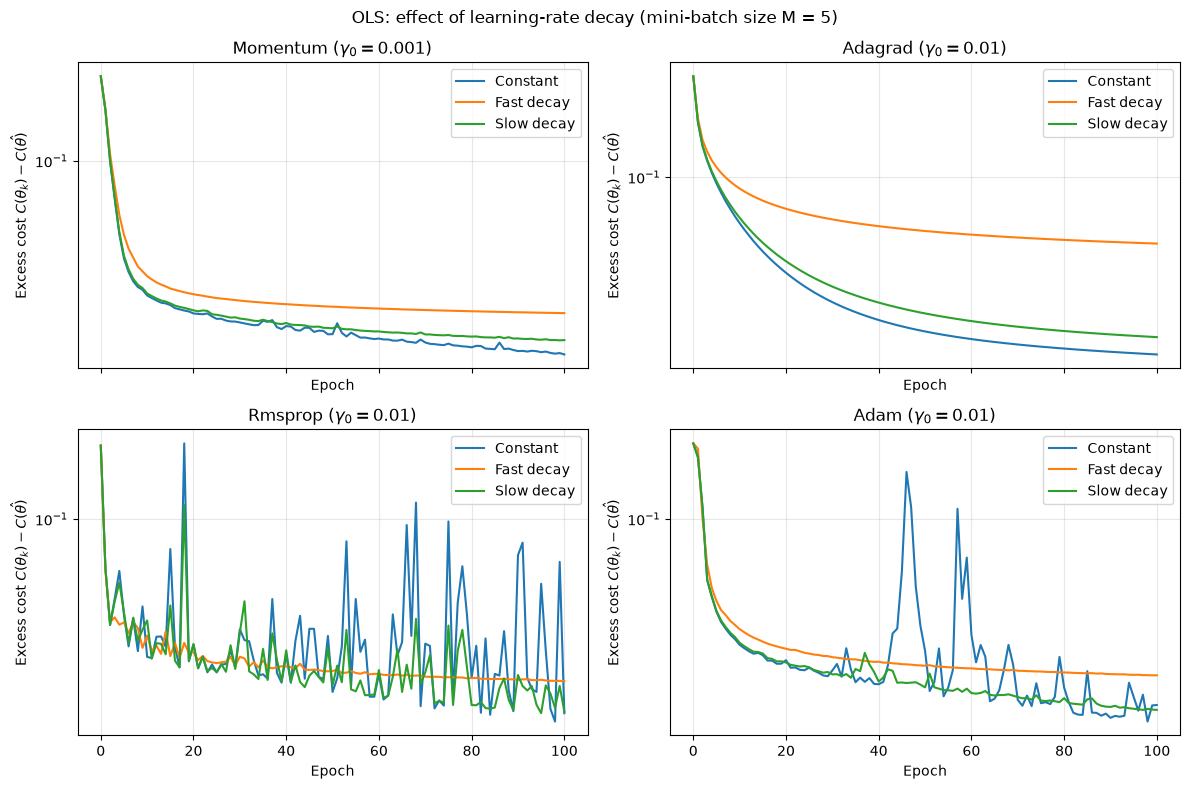

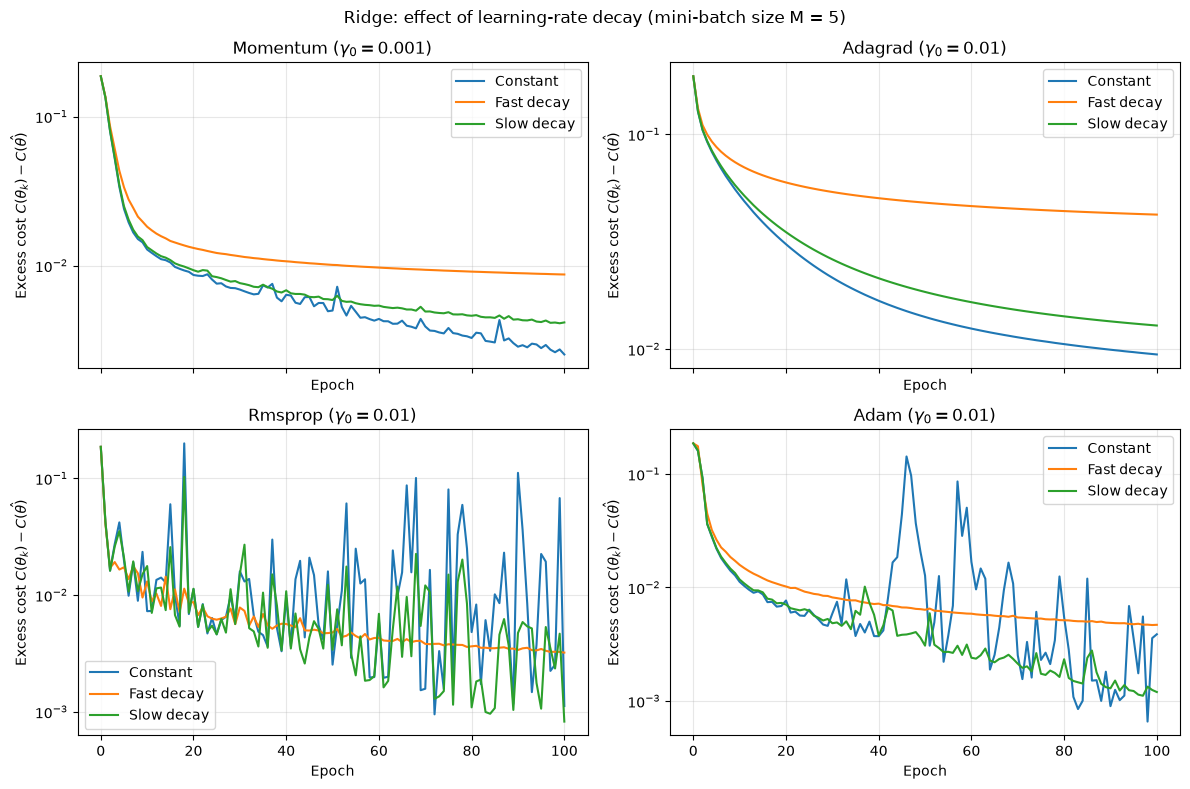

In [48]:
rng = np.random.default_rng(2026)
M = 5
n_epochs = 100


for lam, model in [(0.0, "OLS"), (0.01, "Ridge")]:
    theta_cf = closed_form(X, y, lam=lam)
    best_cost = cost(theta_cf, X, y, lam=lam)

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

    for ax, (method, gamma) in zip(axes.flat, gammas.items()):
        settings = {"Constant": None,"Fast decay": (gamma * 100, 100),"Slow decay": (gamma * 1000, 1000),}

        for label, schedule in settings.items():
            hist = sgd(X, y,method=method,n_epochs=n_epochs,batch_size=M,gamma=gamma,schedule=schedule,lam=lam,seed=2026,)

            excess = np.array([cost(theta, X, y, lam=lam) - best_cost for theta in hist])

            ax.plot(np.arange(len(hist)), excess, label=label)

        ax.set_title(rf"{method.capitalize()} ($\gamma_0={gamma:g}$)")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(r"Excess cost $C(\theta_k)-C(\hat{\theta)}$")
        ax.set_yscale("symlog", linthresh=1e-10)
        ax.grid(alpha=0.3)
        ax.legend()

    fig.suptitle(f"{model}: effect of learning-rate decay "f"(mini-batch size M = {M})")
    fig.tight_layout()
    plt.show()

In [49]:
import time


X, y = Xtr_sc, y_train
n_epochs = 100

gammas = {"momentum": 0.001,"adagrad": 0.01,"rmsprop": 0.01,"adam": 0.01,}

rows = []

for lam, model in [(0.0, "OLS"), (0.01, "Ridge")]:
    theta_cf = closed_form(X, y, lam=lam)
    best_cost = cost(theta_cf, X, y, lam=lam)

    for method, gamma in gammas.items():
        for M in [5, len(y)]:
            start = time.perf_counter()

            hist = sgd(X, y,method=method,batch_size=M,n_epochs=n_epochs,gamma=gamma,lam=lam,schedule=None,seed=2026,)

            elapsed = time.perf_counter() - start

            final_cost = cost(hist[-1], X, y, lam=lam)
            updates = n_epochs * int(np.ceil(len(y) / M))

            rows.append({"Model": model,"Method": method.capitalize(), "Batch size": M, "Updates": updates, "Final excess cost": final_cost - best_cost, "Time (s)": elapsed,})

results = pd.DataFrame(rows)

display(results.style.format({"Final excess cost": "{:.3e}","Time (s)": "{:.3f}", }))

,Model,Method,Batch size,Updates,Final excess cost,Time (s)
0,OLS,Momentum,5,1400,1.897e-02,0.016
1,OLS,Momentum,70,100,3.537e-02,0.002
2,OLS,Adagrad,5,1400,2.786e-02,0.030
3,OLS,Adagrad,70,100,7.197e-02,0.002
4,OLS,Rmsprop,5,1400,1.464e-02,0.021
5,OLS,Rmsprop,70,100,2.177e-02,0.002
6,OLS,Adam,5,1400,1.670e-02,0.023
7,OLS,Adam,70,100,1.931e-02,0.002
8,Ridge,Momentum,5,1400,2.529e-03,0.014
9,Ridge,Momentum,70,100,1.649e-02,0.002


I
-

In [511]:
degrees = np.arange(1, 16)
lambdas = np.logspace(-6, 0, 100)

rng = np.random.default_rng(2026)
sigma = 0.1
n = 100
x = np.sort(rng.uniform(-1,1,n))
y = runge(x) + rng.normal(0, sigma, size = n)    
x = np.asarray(x).reshape(-1, 1)
y = np.asarray(y).ravel()


kf = KFold(n_splits=10, shuffle=True, random_state=2026)
# OLS
ols_mse = np.zeros(len(degrees))
ols_std = np.zeros(len(degrees))
#Ridge
ridge_mse = np.zeros((len(degrees), len(lambdas)))
ridge_std = np.zeros((len(degrees), len(lambdas)))
#Lasso
lasso_mse = np.zeros((len(degrees), len(lambdas)))
lasso_std = np.zeros((len(degrees), len(lambdas)))

#

for i, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    #OLS
    ols_pipe = make_pipeline(poly, LinearRegression())
    mse_folds = -cross_val_score(ols_pipe, x, y, cv=kf,scoring="neg_mean_squared_error")
    
    ols_mse[i] = mse_folds.mean()
    ols_std[i] = mse_folds.std(ddof=1) / np.sqrt(len(mse_folds))

    for j, lam in enumerate(lambdas):
        #Ridge
        ridge_pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),StandardScaler(),Ridge(alpha=lam))
        Rmse_folds = -cross_val_score(ridge_pipe, x, y, cv=kf,scoring="neg_mean_squared_error")
        ridge_mse[i, j] = Rmse_folds.mean()
        ridge_std[i, j] = Rmse_folds.std(ddof=1) / np.sqrt(len(Rmse_folds)).mean()
        #Lasso
        lasso_pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False),StandardScaler(),Lasso(alpha=lam, max_iter=100000, tol=1e-5))
        Lmse_folds = -cross_val_score(lasso_pipe, x, y, cv=kf,scoring="neg_mean_squared_error")
        lasso_mse[i, j] = Lmse_folds.mean()
        lasso_std[i, j] = Lmse_folds.std(ddof=1) / np.sqrt(len(Lmse_folds)).mean()


ols_i = np.argmin(ols_mse)
ridge_i, ridge_j = np.unravel_index(np.argmin(ridge_mse), ridge_mse.shape)
lasso_i, lasso_j = np.unravel_index(np.argmin(lasso_mse), lasso_mse.shape)

C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.855540e-01, tolerance: 9.336e-05
  model = cd_fast.enet_coordinate_descent(
C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.553918e-01, tolerance: 8.382e-05
  model = cd_fast.enet_coordinate_descent(
C:\Users\torae\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCach

In [512]:

table = pd.DataFrame([
    {
        "Method": "OLS",
        "Degree": degrees[ols_i],
        "Lambda": 0.0,
        "CV-MSE": ols_mse[ols_i],
        "Standard error": ols_std[ols_i]
    },
    {
        "Method": "Ridge",
        "Degree": degrees[ridge_i],
        "Lambda": lambdas[ridge_j],
        "CV-MSE": ridge_mse[ridge_i, ridge_j],
        "Standard error": ridge_std[ridge_i, ridge_j]
    },
    {
        "Method": "Lasso",
        "Degree": degrees[lasso_i],
        "Lambda": lambdas[lasso_j],
        "CV-MSE": lasso_mse[lasso_i, lasso_j],
        "Standard error": lasso_std[lasso_i, lasso_j]
    }
])

display(table.style.format({"Degree":"{:.0f}",
                            "Lambda":"{:.3g}",
                            "CV_mse":"{:.4f}",
                            "STD":"{:.4f}",}).hide(axis="index"))

Method,Degree,Lambda,CV-MSE,Standard error
OLS,11,0,0.020237,0.003114
Ridge,12,1.07e-05,0.019176,0.002616
Lasso,15,1.52e-06,0.020010,0.002588


In [97]:
print(
    table.to_latex(
        index=False,
        escape=False,
        na_rep="--",
        formatters={
            "Degree": lambda v: f"{v:.0f}",
            "Lambda": lambda v: f"{v:.3g}",
            "CV-MSE": lambda v: f"{v:.6f}",
            "Standard error": lambda v: f"{v:.6f}"
        },
        caption=(
            "Best polynomial degree and regularization parameter for each "
            "method, selected using 5-fold cross-validation. "
            "Standard errors are estimated from the fold MSE values."
        ),
        label="tab:cv_best"
    )
)

\begin{table}
\caption{Best polynomial degree and regularization parameter for each method, selected using 5-fold cross-validation. Standard errors are estimated from the fold MSE values.}
\label{tab:cv_best}
\begin{tabular}{lrrrr}
\toprule
Method & Degree & Lambda & CV-MSE & Standard error \\
\midrule
OLS & 11 & 0 & 0.021113 & 0.003240 \\
Ridge & 12 & 1.87e-05 & 0.020680 & 0.002687 \\
Lasso & 15 & 1e-06 & 0.021216 & 0.002655 \\
\bottomrule
\end{tabular}
\end{table}

